# 01 - The four bridge states

## Purpose

This notebook is the second in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
00 characterized the measurement chain. This notebook establishes what the
H-bridge does to the measured channels in each of its four output states,
so that later notebooks can gate every sample on the state the bridge was
in when the sample was taken.

This notebook has three jobs:

1. Establish, from data, what each bridge state does to the terminal
   voltages, the shunt current and the motion (section 5).
2. Produce the per-state sample-validity map that the later notebooks gate
   on (section 5.4).
3. Measure the coast and brake spin-down behavior (section 6).

The dataset is the `bridge` experiment of two campaigns, one on a 2-cell
lithium battery and one on a laptop USB port, on the same servo and the
same board. Each capture holds three sweeps taken back to back.

**The 2S campaign is primary and every number below comes from it.** The
USB campaign is a cross-check: it answers whether a level, an edge or a
slope moves the way the rail says it should, and nothing is fitted to it.
The reason is the same as in notebook 00. The USB rail droops a few
percent across the duty range and dips much further on spin-up, so any
quantity fitted against duty on USB has rail droop folded into its duty
axis. The 2S rail is flat.

Where a number depends on the rail (speeds, EMF magnitudes, the levels the
floating terminals reach, the duty at which the diode phase starts) I say
so, and the USB column is the check that it moves in the right direction
by the right factor.

## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebook 00, summarized here with the additions this
notebook needs. Both campaigns ran on that one board, so nothing below
compares measurement chains.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The bridge has four output states. **Forward drive** and
  **reverse drive** connect the supply across the motor in either
  polarity. **Brake** pulls both outputs low, so the winding is shorted
  through the two low-side switches. **Coast** turns every switch off, so
  both terminals float.
- **Duty** is the fraction of each PWM period in the drive state. The
  **decay mode** selects what the bridge does for the rest of the period.
  Under **slow decay** the OFF portion is brake. Under **fast decay** the
  OFF portion is coast.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts here, because the servo entry's pot scale is disputed by 9%
  (it prints with its bracket in section 2).
- A shunt resistor in the motor return path, amplified and read by the
  ADC, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included. Current crosses the
  shunt only while the bridge drives. In brake the current recirculates
  through the low-side switches. In coast it returns through the switch
  body diodes, crossing the shunt in the negative direction until it dies.
- Both motor terminals are read through resistor dividers, channels
  `vmotor_a` and `vmotor_b`. The bottom leg of each divider returns to a
  bias node $V_B$ instead of ground, so a terminal that swings well below
  ground keeps its ADC pin above ground and stays readable (section 2
  gives the tap formula). Each tap carries a reservoir capacitor so the
  ADC's sample capacitor can charge quickly.
- The ADC, clocked at 24 MHz, runs two scans per 50 us period, one
  triggered at the crest of the PWM counter and one at the trough. Under
  slow decay the drive window is centered on the crest. Under fast decay
  it is centered on the trough. Section 5.1 works out which scan sees
  which state.
- The controller streams every sample at the control rate, packed 16
  samples to a frame with a CRC, with the crest scan's shunt, both
  terminals and position, plus the trough scan's shunt. Corrupted frames
  are dropped and counted, so corruption turns into missing samples
  (verified in section 4).

**The board is a hacked rig.** The board under both campaigns is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). Its registry entry says so and prints in section 2. I know
of one defect on it that the next board revision does not have. The bus
telemetry stream couples into the current amplifier's output, so a shunt
sample taken while a frame is going out on the wire can read a few counts
off. On the scan geometry of this firmware build it does not show at rest
(notebook 00, section 5.2, bins the rest current by position inside the
frame and finds it flat within a count), but it is a known limitation of
this board, and I do not code around it anywhere in this notebook.

The rails, measured at the driven terminal in section 5.2: the 2S pack
sits at about 7.6 V and is flat across the duty range; the USB port sits
at about 4.6 V and sags with duty. Every speed and every EMF on USB is
therefore smaller than on 2S for the supply alone.

## 2. Constants and unit conversions

No constant is written into this notebook. Each dataset's `manifest.json`
names a board and a servo, and the entries in `oscnb/boards.py` and
`oscnb/servos.py` carry every conversion, floor and measured value. The
cell below selects the primary dataset and prints them, so a reader on
GitHub can check the numbers without running anything. The shunt, the
divider legs, the amplifier gain and VDD are also in each recording's
`meta.json` (the `sense` block), and reading a recording checks that block
against the board and raises on a mismatch.

A duty $d$ places the drive window with half-width $1200 d$ ticks around
its center and the OFF window with half-width $1200 (1 - d)$ ticks around
the opposite extreme of the counter. The sampling floors state how far
inside a window the scan must sit for the sample to be settled. They apply
to both windows: a drive-window sample is settled at or above the floor,
an OFF-window sample at or below 100% minus the floor. The board entry
marks the floors UNVERIFIED against the flashed firmware; notebook 00,
section 5.4, shows this dataset is consistent with the 160-tick figure and
rules out the 120-tick alternative. The streamed `window_valid` flag
encodes the current floor of the drive window.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

With the bridge off and no current, both taps read $V_B$ exactly, which is
how the bias is measured per sweep (section 3). The two taps do not read
quite the same bias at rest: they differ by four counts, the same in every
sweep of both campaigns, and notebook 00 section 5.3 leaves the cause open
with the experiment that would settle it. So every absolute terminal
voltage below uses the second form with the rest reading of its own
terminal in its own sweep, which absorbs the split as an offset. The
difference $v_A - v_B$ is then $r\,(\text{tap}_A - \text{tap}_B)$ minus the
rest split, and it reads zero at rest.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage scales with the true VDD of this unit. The
divider, shunt and gain are design values with unmeasured tolerances.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import least_squares

import oscnb

# The only constant this notebook owns: duty is encoded on the wire as a
# signed q15 fraction.
Q15 = 32767

DATASETS = {"2s": "sg90-a__dev-v006-D__2s", "usb": "sg90-a__dev-v006-D__usb"}
DS = {k: oscnb.datasets.load(v) for k, v in DATASETS.items()}

# 2S is primary. Selecting it prints the rig this notebook reports against.
ds = oscnb.use(DATASETS["2s"])
board, servo = oscnb.current().board, oscnb.current().servo

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [18.07, 18.49] ripple tach v... counts/deg            18.2900
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.29, 7.49] ripple speed + coast B... mV per motor rev/s     7.3670


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           18.290           counts/deg    [18.07, 18.49]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.367   mV per motor rev/s      [7.29, 7.49]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         ripple tach vs counted gear ratio, 2S grid 30-...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                ripple speed + coast BEMF, 2S bridge spindown,...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

## 3. Capture method

The recordings live under `notebooks/telemetry/<dataset>/bridge/`, one
folder per capture. Each capture holds three sweeps, taken back to back
with the same servo state:

- **Slow-decay sweep.** Segment 0 is a one-second baseline with the bridge
  disabled. Segments 1 to 40 are constant-duty drive steps, 5% to 100% in
  5% increments, first forward then reverse, under slow decay.
- **Fast-decay sweep.** The same grid under fast decay.
- **Spin-down sweep.** Slow decay. Segment 0 is the baseline. Then, for
  20%, 30% and 40% duty in turn, an 80 ms drive step followed by 400 ms of
  coast, and a second drive step at the same duty followed by 400 ms of
  brake. The pattern runs forward first, then reverse, 24 segments in all.
  The zero-duty segments start when the drive command ends, so the motor
  enters them at whatever speed the drive step reached.

The drive steps of the slow and fast sweeps are **not** a fixed 80 ms.
Each rung's window is sized from that supply's own steady-speed fit so
every rung travels about the same distance inside the travel envelope; the
schedule prints in each sweep's metadata as `duty@milliseconds`. On 2S the
windows run from 1500 ms at 5% duty down to 124 ms at 100%, on USB from
1500 ms down to 197 ms. Only the spin-down sweep keeps the fixed 80 ms
drive step, because there its job is to set an entry speed, not to travel
a set distance.

Before every drive step the servo is repositioned at 15% duty toward the
far end of travel, so the step has room to accelerate. The mechanism can
still be moving from that repositioning move when the step begins, in the
direction opposite to the step. Speed at the end of a drive step therefore
varies from step to step, and the entry speed into every coast and brake
segment is measured from the data (section 6).

**Data acceptance.** A capture is accepted only if the host counted zero
dropped frames in all three sweeps, and one warm-up capture per experiment
was discarded. Section 4 re-verifies the frame count from the data itself.

Each row of a sweep is one 50 us sample: segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The spin-down sweep's metadata lists the schedule, from which
the kind of every zero-duty segment (coast or brake) follows.

The segment-0 baseline of every sweep gives three per-sweep constants, the
shunt amplifier's bias (mean of `current_raw`) and the rest reading of
each terminal (median of `vmotor_a` and of `vmotor_b`), which are the
$V_B$ of terminal A and of terminal B in the tap formula. The table lists
both rest readings per capture, their split, and how much each one moves
across the three sweeps of a capture.

In [2]:
SWEEPS = ("slow", "fast", "spindown")

# Only the streamed columns are kept, as int32: the two campaigns together
# are ten million samples.
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid", "pos",
        "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

def load_sweep(dataset, capture, name):
    # One sweep = <name>.csv.gz plus <name>.meta.json. rec.frame() checks the
    # recording's `sense` block against the board the manifest names.
    # Derived columns: duty_pct (signed percent), mag_pct (rounded
    # magnitude), and the per-sweep baseline constants bias (shunt amplifier
    # offset), vb (terminal A rest reading), vb_b (terminal B).
    rec = next(r for r in dataset.recordings("bridge", capture) if r.name == name)
    df = rec.frame()[KEEP].astype("int32")
    meta = rec.meta
    df["duty_pct"] = (df["cmd_duty_q15"] * (100.0 / Q15)).astype("float32")
    df["mag_pct"] = df["duty_pct"].abs().round().astype("int16")
    base = df[df["seg"] == 0]
    df["bias"] = np.float32(base["current_raw"].mean())
    df["vb"] = np.float32(base["vmotor_a"].median())
    df["vb_b"] = np.float32(base["vmotor_b"].median())
    if name == "spindown":
        # Segment k (k >= 1) is schedule entry (k - 1) mod len(schedule).
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def terms_V(seg):
    # Both terminals in absolute volts, each corrected with its own rest
    # reading from the sweep's baseline (section 2).
    return (board.term_v(seg["vmotor_a"].to_numpy(), seg["vb"].iloc[0]),
            board.term_v(seg["vmotor_b"].to_numpy(), seg["vb_b"].iloc[0]))

# 2S first, and first is primary.
RECS = {k: {cap: {n: load_sweep(DS[k], cap, n) for n in SWEEPS}
            for cap in DS[k].captures("bridge")}
        for k in ("2s", "usb")}
PRIMARY = "2s"
COLORS = {"2s": "tab:blue", "usb": "tab:orange"}

rows = []
for label, recs in RECS.items():
    for name, sweeps in recs.items():
        a = [sweeps[s][0]["vb"].iloc[0] for s in SWEEPS]
        b = [sweeps[s][0]["vb_b"].iloc[0] for s in SWEEPS]
        rows.append({
            "series": label,
            "capture": name,
            "VB_A [counts]": a[0],
            "VB_B [counts]": b[0],
            "B minus A [counts]": b[0] - a[0],
            "A spread over sweeps [counts]": max(a) - min(a),
            "B spread over sweeps [counts]": max(b) - min(b),
            "VB_A minus nominal [mV]": (a[0] * board.v_adc_per_count - board.vb_nom_v) * 1e3,
            "VB_B minus nominal [mV]": (b[0] * board.v_adc_per_count - board.vb_nom_v) * 1e3,
        })
pd.DataFrame(rows).set_index(["series", "capture"]).round(2)

VB_A [counts]  VB_B [counts]  B minus A [counts]  \
series capture                                                       
2s     capture-1          778.0          782.0                 4.0   
       capture-2          778.0          782.0                 4.0   
       capture-3          778.0          782.0                 4.0   
       capture-4          778.0          782.0                 4.0   
       capture-5          778.0          782.0                 4.0   
usb    capture-1          778.0          782.0                 4.0   
       capture-2          778.0          782.0                 4.0   
       capture-3          778.0          782.0                 4.0   
       capture-4          778.0          782.0                 4.0   
       capture-5          778.0          782.0                 4.0   

                  A spread over sweeps [counts]  \
series capture                                    
2s     capture-1                            0.0   
       capture-2                            0.0   
       capture-3                            0.0   
       capture-4                            0.0   
       capture-5                            0.0   
usb    capture-1                            1.0   
       capture-2                            1.0   
       capture-3                            0.0   
       capture-4                            0.0   
       capture-5                            0.0   

                  B spread over sweeps [counts]  VB_A minus nominal [mV]  \
series capture                                                             
2s     capture-1                            0.0                    -1.13   
       capture-2                            0.0                    -1.13   
       capture-3                            0.0                    -1.13   
       capture-4                            0.0                    -1.13   
       capture-5                            0.0                    -1.13   
usb    capture-1                            0.0                    -1.13   
       capture-2                            0.0                    -1.13   
       capture-3                            0.0                    -1.13   
       capture-4                            0.0                    -1.13   
       capture-5                            0.0                    -1.13   

                  VB_B minus nominal [mV]  
series capture                             
2s     capture-1                     2.09  
       capture-2                     2.09  
       capture-3                     2.09  
       capture-4                     2.09  
       capture-5                     2.09  
usb    capture-1                     2.09  
       capture-2                     2.09  
       capture-3                     2.09  
       capture-4                     2.09  
       capture-5                     2.09

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every sweep in every capture from
the tick column, which increments by one per sample within a segment.

In [3]:
rows = []
for label, recs in RECS.items():
    for name, sweeps in recs.items():
        for sweep, (df, meta) in sweeps.items():
            missing = 0
            for _, seg in df.groupby("seg"):
                ticks = seg["tick"].to_numpy()
                missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
            rows.append({"series": label, "capture": name, "sweep": sweep,
                         "samples": len(df), "segments": df["seg"].nunique(),
                         "missing_samples": missing})
integ = pd.DataFrame(rows)
integ.groupby(["series", "sweep"]).agg(captures=("capture", "count"),
                                       segments=("segments", "max"),
                                       samples=("samples", "max"),
                                       missing_samples=("missing_samples", "sum"))

captures  segments  samples  missing_samples
series sweep                                                 
2s     fast             5        41   336800                0
       slow             5        41   336800                0
       spindown         5        25   135200                0
usb    fast             5        41   483640                0
       slow             5        41   483640                0
       spindown         5        25   135200                0

Every sweep of every capture has zero missing samples, in both campaigns.

## 5. The four states

### 5.1 Which scan sees which state

The two scans per period sit at the two extremes of the center-aligned
PWM counter. The drive window is centered on the crest under slow decay
and on the trough under fast decay, so each scan sees a different bridge
state depending on the decay mode:

| Decay | Crest scan (`current_raw`, `vmotor_a`, `vmotor_b`) | Trough scan (`current_trough`) |
|---|---|---|
| Slow | drive | brake |
| Fast | coast | drive |

Only the shunt is streamed from the trough scan, so the terminal voltages
of the brake state come from the spin-down sweep's brake segments (a brake
state lasting the whole period, seen by the crest scan) and the terminal
voltages of the coast state come from the fast-decay sweep's crest scan
and the spin-down sweep's coast segments. The rest of section 5 checks
each cell of this table against the data.

### 5.2 Slow decay

Under slow decay the crest scan reads the drive state. The figure shows
the primary campaign: the crest-scan shunt current (bias subtracted,
converted to amperes) and the two terminals against duty, per capture, for
both directions. The trough scan reads the brake state, and its shunt
reading is plotted as an offset from the baseline bias.

Per drive step the terminal levels and the current are the median of the
step. The table pools the captures per signed duty at a few grid points
and puts the two campaigns side by side, so the two terminals can be
compared with each other and the rail dependence can be read off.

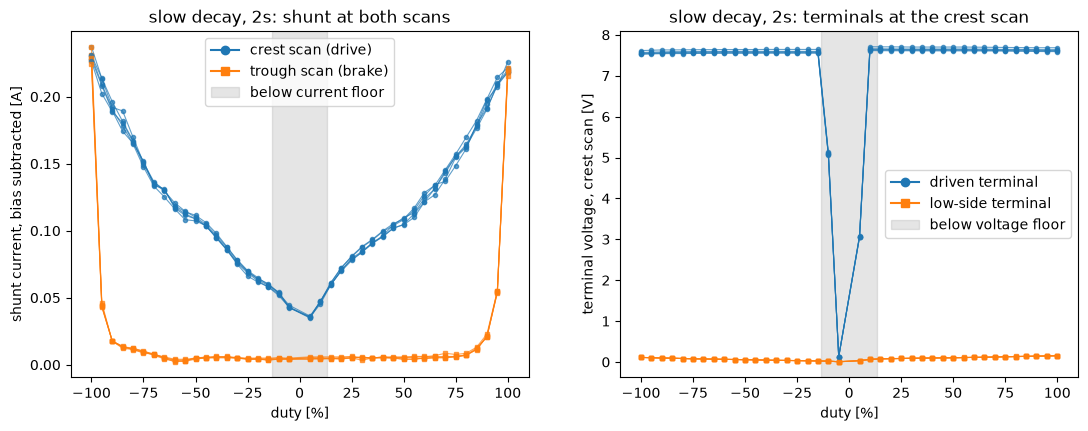

2s                                                         \
            valid_frac crest_current_A trough_offset_counts driven_terminal_V   
duty_pct                                                                        
-100.000000        1.0           0.230              256.423             7.560   
-94.998016         1.0           0.209               49.323             7.567   
-89.999084         1.0           0.191               19.723             7.573   
-84.997101         1.0           0.181               14.723             7.577   
-69.997253         1.0           0.135                8.523             7.582   
-49.998474         1.0           0.109                5.323             7.585   
-29.999695         1.0           0.077                5.723             7.587   
-19.998779         1.0           0.063                4.923             7.587   
-14.999847         1.0           0.059                4.523             7.587   
-9.997864          0.0           0.053                5.123             5.093   
-4.998932          0.0           0.043                4.923             0.130   
 4.998932          0.0           0.036                5.523             3.066   
 9.997864          0.0           0.047                5.523             7.651   
 14.999847         1.0           0.060                5.523             7.649   
 19.998779         1.0           0.071                5.523             7.647   
 29.999695         1.0           0.086                5.523             7.646   
 49.998474         1.0           0.107                5.523             7.645   
 69.997253         1.0           0.142                6.923             7.640   
 84.997101         1.0           0.179               13.323             7.633   
 89.999084         1.0           0.195               23.923             7.629   
 94.998016         1.0           0.210               60.923             7.627   
 100.000000        1.0           0.221              244.523             7.627   

                                      usb                  \
            lowside_terminal_V valid_frac crest_current_A   
duty_pct                                                    
-100.000000              0.112        1.0           0.109   
-94.998016               0.104        1.0           0.102   
-89.999084               0.097        1.0           0.099   
-84.997101               0.092        1.0           0.094   
-69.997253               0.074        1.0           0.080   
-49.998474               0.056        1.0           0.069   
-29.999695               0.037        1.0           0.051   
-19.998779               0.029        1.0           0.042   
-14.999847               0.025        1.0           0.039   
-9.997864                0.020        0.0           0.035   
-4.998932                0.005        0.0           0.024   
 4.998932                0.031        0.0           0.021   
 9.997864                0.063        0.0           0.033   
 14.999847               0.076        1.0           0.039   
 19.998779               0.081        1.0           0.043   
 29.999695               0.090        1.0           0.053   
 49.998474               0.103        1.0           0.067   
 69.997253               0.122        1.0           0.082   
 84.997101               0.137        1.0           0.096   
 89.999084               0.142        1.0           0.100   
 94.998016               0.148        1.0           0.105   
 100.000000              0.152        1.0           0.108   

                                                                       
            trough_offset_counts driven_terminal_V lowside_terminal_V  
duty_pct                                                               
-100.000000               121.56             4.488              0.058  
-94.998016                 40.76             4.519              0.055  
-89.999084                 30.56             4.530              0.054  
-84.997101                 27.16    

lowside_R_B_ohm               lowside_R_A_ohm              
                  mean    min    max            mean    min    max
series                                                            
2s               0.536  0.529  0.556           0.553  0.534  0.561
usb              0.531  0.519  0.552           0.598  0.579  0.618

In [4]:
def slow_steps(df):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        vA, vB = terms_V(seg)
        hi, lo = (vA, vB) if d > 0 else (vB, vA)   # driven and low-side terminal
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * board.a_per_count,
            "trough_offset_counts": seg["current_trough"].median() - seg["bias"].iloc[0],
            "driven_terminal_V": np.median(hi),
            "lowside_terminal_V": np.median(lo),
        })
    return pd.DataFrame(out).sort_values("duty_pct")

SLOW = {label: {name: slow_steps(sw["slow"][0]) for name, sw in recs.items()}
        for label, recs in RECS.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, st in SLOW[PRIMARY].items():
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["trough_offset_counts"] * board.a_per_count, "-s", ms=3,
                 lw=0.8, color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["driven_terminal_V"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["lowside_terminal_V"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
axes[0].plot([], [], "-o", color="tab:blue", label="crest scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="trough scan (brake)")
axes[0].axvspan(-board.floor_i_pct, board.floor_i_pct, color="grey", alpha=0.2,
                label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title(f"slow decay, {PRIMARY}: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "-o", color="tab:blue", label="driven terminal")
axes[1].plot([], [], "-s", color="tab:orange", label="low-side terminal")
axes[1].axvspan(-board.floor_v_pct, board.floor_v_pct, color="grey", alpha=0.2,
                label="below voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("terminal voltage, crest scan [V]")
axes[1].set_title(f"slow decay, {PRIMARY}: terminals at the crest scan")
axes[1].legend()
plt.show()

# Pooled over captures, by signed duty, at a few grid points per direction.
show = [5, 10, 15, 20, 30, 50, 70, 85, 90, 95, 100]
cols = ["valid_frac", "crest_current_A", "trough_offset_counts",
        "driven_terminal_V", "lowside_terminal_V"]
pooled = {}
for label in RECS:
    allst = pd.concat(SLOW[label].values())
    pooled[label] = allst[allst["mag_pct"].isin(show)].groupby("duty_pct")[cols].mean()
display(pd.concat(pooled, axis=1).round(3))

# Low-side on-resistance plus shunt, per terminal and per campaign: B is the
# low side when driving forward, A in reverse.
rows = []
for label in RECS:
    for name, st in SLOW[label].items():
        e = {"series": label, "capture": name}
        for sub, key in [(st[st["duty_pct"] > 0], "lowside_R_B_ohm"),
                         (st[st["duty_pct"] < 0], "lowside_R_A_ohm")]:
            ok = sub[(sub["mag_pct"] >= 20) & (sub["mag_pct"] <= 85)]
            e[key] = np.polyfit(ok["crest_current_A"], ok["lowside_terminal_V"], 1)[0]
        rows.append(e)
lowside_R = pd.DataFrame(rows).set_index(["series", "capture"])
lowside_R.groupby("series").agg(["mean", "min", "max"]).round(3)

Findings for the drive state (crest scan), on 2S:

- The shunt current rises with duty from the first step. The validity flag
  sets from the 15% step in every capture, the first grid point above the
  13.3% floor. The current curve passes through the flag edge without a
  kink. At 100% duty the current is 0.221 A forward and 0.230 A reverse.
  USB reads 0.108 and 0.109 A at the same step. The rails are 7.63 V and
  4.53 V, a factor 1.68, while the currents differ by a factor 2.0: the
  motor is also spinning faster on 2S, but not proportionally, so the
  back-EMF does not scale the current away.
- The driven terminal reads the rail from the 10% step in both directions,
  7.651 V forward and 7.587 V reverse on 2S. At 5% terminal A reads 3.07 V
  and terminal B 0.13 V, so on the 0.1 V criterion of section 5.4 neither
  terminal is settled at 5% and both are from 10%; the 13.3% configured
  floor is the conservative edge and notebook 00 section 5.4 shows why it
  has to be (terminal B is still 2.5 V low at the 10% step of the slow
  grid there).
- The rail is flat with duty on 2S, 7.651 V at 10% and 7.627 V at 100%, a
  change of -0.3%. On USB the same measure gives 4.686 V and 4.531 V,
  -3.3%. That contrast is the whole reason the fits below are on 2S.
- The two terminals do not read alike, but the disagreement is now an
  offset and not a slope. The low-side terminal rises with current with a
  slope of 0.536 Ohm on B and 0.553 Ohm on A (2S), the on-resistance of the
  low-side switch plus the shunt; USB gives 0.531 and 0.598. On top of that
  slope sits a fixed offset: at the 15% step terminal B reads 0.076 V as
  the low side of forward drive and terminal A reads 0.025 V as the low
  side of reverse drive, and the gap stays about 40 mV all the way to full
  duty. The driven terminal likewise reads about 60 mV higher on A than on
  B at the same duty. Divider tolerance (1% resistors, so about 1.4% on
  $r$, which is 107 mV at 7.6 V) can explain a difference of that size at
  the rail, but not a 50 mV difference at 0.05 V. Section 9 has the
  candidate causes and the experiment.

Findings for the brake state (trough scan), on 2S:

- The trough shunt sits about 5.5 counts above the baseline bias and stays
  there, within a count, from 5% all the way to 50% duty. Above that it
  grows: 6.9 counts at 70%, 13.3 at 85%, 23.9 at 90%, 60.9 at 95%, and at
  100% it equals the drive current, because there is no OFF window left.
  This matches the 86.7% OFF-window floor from section 2.
- USB behaves the same way but worse at every duty: 4 to 5 counts at low
  duty, 7.8 at 50%, 14.6 at 70%, 26.0 at 85%, 46.2 at 95%. At 70% duty USB
  reads twice the offset of 2S while carrying **half** the drive current.
  That is the opposite of what an amplifier recovering from the drive pulse
  would do, and it is section 9's first entry.
- The few-count floor of the offset shows up again in the fast-decay coast
  window (section 5.3) and in the spin-down brake and coast segments
  (section 5.4). Every OFF-state shunt sample sits about 5 counts (4.5 mA
  equivalent) above the bridge-disabled baseline on 2S and about 3.4 counts
  on USB. So a live bias tracker that runs while the bridge is enabled will
  settle a few counts above the baseline of section 3, which is fine as
  long as the drive current is referenced to the same tracker.

The brake state's terminal voltages come from the spin-down sweep in
section 6. Both terminals sit within 0.03 V of ground for the whole brake
segment, which puts their taps near two thirds of the bias (table in
section 5.4).

### 5.3 Fast decay

Under fast decay the trough scan reads the drive state and the crest scan
reads the coast state. The left panel shows the shunt at both scans. The
right panel shows the sum of the two crest-scan terminals, $v_A + v_B$,
which serves as the phase discriminator of the coast window. At rest both
terminals read their own bias, so the sum's baseline is $V_{B,A} +
V_{B,B}$, about 1.26 V. A floating terminal cannot exceed the rail. A
terminal reading above it is being held there by a conducting high-side
body diode, which means winding current is still flowing, and the sum then
exceeds the rail as well, since the other terminal cannot fall below its
clamp. The measured rail (section 5.2) is drawn as the discriminator
threshold. The table lists both campaigns.

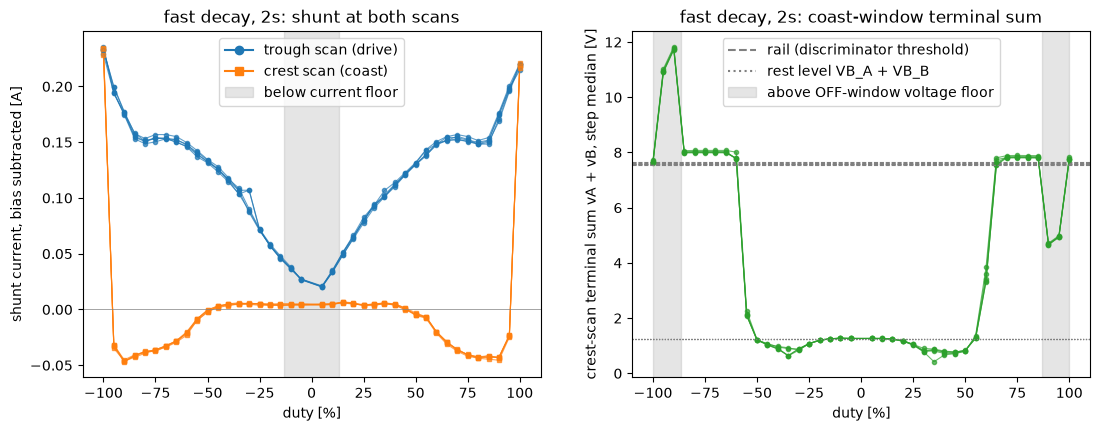

2s                                                 \
        trough_current_A crest_current_A high_terminal_V low_terminal_V   
mag_pct                                                                   
5                  0.024           0.004           0.623          0.641   
10                 0.036           0.005           0.603          0.664   
15                 0.048           0.005           0.554          0.694   
20                 0.061           0.005           0.466          0.721   
25                 0.076           0.004           0.314          0.746   
30                 0.094           0.005           0.072          0.772   
35                 0.104           0.005          -0.055          0.810   
40                 0.114           0.004          -0.036          0.779   
45                 0.124           0.002          -0.301          0.902   
50                 0.132          -0.003          -0.417          1.333   
55                 0.140          -0.008          -0.427          2.153   
60                 0.148          -0.021          -0.439          6.087   
65                 0.152          -0.029          -0.463          8.316   
70                 0.154          -0.035          -0.487          8.422   
75                 0.153          -0.039          -0.499          8.433   
80                 0.150          -0.041          -0.506          8.439   
85                 0.153          -0.042          -0.521          8.446   
90                 0.175          -0.045           1.341          6.881   
95                 0.197          -0.028           6.074          1.880   
100                0.226           0.226           7.588          0.132   

                                                       usb                  \
        sum_median_V diode_frac travel_mV trough_current_A crest_current_A   
mag_pct                                                                      
5              1.264      0.000   -36.053            0.014           0.003   
10             1.268      0.000     7.130            0.022           0.004   
15             1.247      0.000    -0.000            0.029           0.004   
20             1.188      0.000    -0.121            0.036           0.004   
25             1.060      0.000    -2.820            0.044           0.003   
30             0.845      0.000     9.708            0.052           0.003   
35             0.755      0.000   205.444            0.061           0.005   
40             0.835      0.000   485.614            0.067           0.004   
45             0.897      0.009   617.260            0.070           0.004   
50             1.014      0.101   722.681            0.074           0.002   
55             1.728      0.283   817.467            0.078           0.001   
60             5.663      0.455   925.708            0.081           0.000   
65             7.840      0.578  1074.877            0.083          -0.003   
70             7.929      0.668  1252.123            0.085          -0.007   
75             7.931      0.721  1419.540            0.086          -0.010   
80             7.931      0.782  1568.467            0.086          -0.011   
85             7.926      0.829  1695.802            0.087          -0.010   
90             8.222      0.449  1834.698            0.094          -0.008   
95             7.954      0.490  1949.868            0.102           0.001   
100            7.718      0.921  2034.463            0.109           0.109   

                                                                          
        high_terminal_V low_terminal_V sum_median_V diode_frac travel_mV  
mag_pct                                                                   
5                 0.626          0.638        1.264      0.000   -19.497  
10                0.616          0.654        1.269      0.000     0.161  
15                0.587          0.674        1.262      0.000     0.121  
20                0.545          0.697        1.241

In [5]:
def rail_V(sweeps):
    # Supply rail per capture: median driven terminal over the valid
    # slow-decay drive steps at 20% and above, each terminal with its own
    # rest bias. Used as the diode-phase threshold.
    df = sweeps["slow"][0]
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1) & (df["mag_pct"] >= 20)]
    vA, vB = terms_V(v)
    return float(np.median(np.where(v["duty_pct"] > 0, vA, vB)))

def fast_steps(df, rail):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        vA, vB = terms_V(seg)
        hi, lo = (vA, vB) if d > 0 else (vB, vA)   # terminal driven high, driven low
        ssum = vA + vB
        p = seg["pos"].to_numpy() * board.v_adc_per_count
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "trough_current_A": (seg["current_trough"].median() - seg["bias"].iloc[0]) * board.a_per_count,
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * board.a_per_count,
            "high_terminal_V": np.median(hi),
            "low_terminal_V": np.median(lo),
            "sum_median_V": np.median(ssum),
            "diode_frac": (ssum > rail).mean(),
            "travel_mV": (np.median(p[-20:]) - np.median(p[:20])) * 1e3 * np.sign(d),
        })
    return pd.DataFrame(out).sort_values("duty_pct")

RAILS = {label: {name: rail_V(sw) for name, sw in recs.items()}
         for label, recs in RECS.items()}
FAST = {label: {name: fast_steps(recs[name]["fast"][0], RAILS[label][name])
                for name in recs}
        for label, recs in RECS.items()}
# rest level of the terminal sum: VB_A + VB_B, each from its own tap
REST_SUM = {label: {name: (sw["slow"][0]["vb"].iloc[0] + sw["slow"][0]["vb_b"].iloc[0])
                    * board.v_adc_per_count for name, sw in recs.items()}
            for label, recs in RECS.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, st in FAST[PRIMARY].items():
    axes[0].plot(st["duty_pct"], st["trough_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["sum_median_V"], "-o", ms=3, lw=0.8,
                 color="tab:green", alpha=0.7)
    axes[1].axhline(RAILS[PRIMARY][name], color="grey", lw=0.8, ls="--")
    axes[1].axhline(REST_SUM[PRIMARY][name], color="grey", lw=0.8, ls=":")
axes[0].plot([], [], "-o", color="tab:blue", label="trough scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="crest scan (coast)")
axes[0].axhline(0, color="grey", lw=0.5)
axes[0].axvspan(-board.floor_i_pct, board.floor_i_pct, color="grey", alpha=0.2,
                label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title(f"fast decay, {PRIMARY}: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "--", color="grey", label="rail (discriminator threshold)")
axes[1].plot([], [], ":", color="grey", label="rest level VB_A + VB_B")
axes[1].axvspan(-100, -(100 - board.floor_v_pct), color="grey", alpha=0.2)
axes[1].axvspan(100 - board.floor_v_pct, 100, color="grey", alpha=0.2,
                label="above OFF-window voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("crest-scan terminal sum vA + vB, step median [V]")
axes[1].set_title(f"fast decay, {PRIMARY}: coast-window terminal sum")
axes[1].legend(loc="upper center")
plt.show()

cols = ["trough_current_A", "crest_current_A", "high_terminal_V",
        "low_terminal_V", "sum_median_V", "diode_frac", "travel_mV"]
pooled = {label: pd.concat(FAST[label].values()).groupby("mag_pct")[cols].mean()
          for label in RECS}
pd.concat(pooled, axis=1).round(3)

Findings for the drive state (trough scan):

- The trough shunt reads the drive current, rising monotonically from 5%
  to 100%, and the validity flag sets from the 15% step as under slow
  decay. The same floor applies to both decay modes.

Findings for the coast state (crest scan) on 2S, by duty range:

- **5% to 40%.** The crest shunt reads the bias plus the few-count
  OFF-state offset of section 5.2 (0.004 to 0.005 A). Both terminals sit
  near the bias. The terminal driven low reads 0.64 to 0.81 V, a little
  above it, and the terminal driven high drifts below it as duty grows,
  from 0.62 V at 5% to 0.07 V at 30% and -0.06 V at 35%. The position
  column shows no net motion up to 30%. USB shows the same shape and moves
  one rung later, first net travel at 40% against 35% on 2S, which is the
  rail: 35% of 7.6 V is 2.7 V against 35% of 4.6 V, or 1.6 V. *Hypothesis
  (not tested here): the drive pulse is too short for the current to build
  against the winding inductance, so conduction is discontinuous and the
  average torque falls below the friction threshold.*
- **65% to 85%.** The terminal driven low sits at 8.42 V, one diode drop
  (0.83 V) above the 7.60 V rail, in most samples of each step, and the
  terminal driven high at -0.50 V, one body-diode drop below ground. This
  is the diode phase. Winding current is still flowing when the scan fires,
  returning through the high-side body diode of the terminal that was
  driven low and the low-side body diode of the terminal that was driven
  high, and both drops are now readable. The crest shunt reads below the
  bias in the same range, the freewheel current crossing the shunt
  backward, growing from -0.029 A at 65% to -0.042 A at 85%. USB runs the
  same phase from 80% to 85% with drops of 0.71 V and -0.52 V and a
  freewheel current about a quarter of the size. The diode drop itself is
  the only part that should not scale with the rail, and it does not
  scale: 0.83 V against 0.71 V at a rail 1.65 times higher.
- **45% to 60%.** The terminal driven high reaches the clamp, -0.30 V at
  45% and -0.42 V at 50%, while the terminal driven low rises steeply from
  0.90 V to 2.15 V and then to 6.09 V at 60%. Under one tenth of the 50%
  step is above the rail. The next code cell examines what this reading is.
- **90% to 100%.** The OFF window shrinks toward the terminal slots'
  offset from the crest, and the two terminals stop agreeing on which
  state they are in: at 90% the step median has the terminal driven high
  back at 1.34 V and the sum still above the rail in 45% of samples. The
  configured 86.7% OFF-window floor is the conservative edge and the map in
  section 5.4 stops the diode phase at 85%. At 100% both scans read the
  drive state.

The terminal reading in the 45% to 60% range needs a closer look. If it
were the back-EMF of a spinning motor, it would grow with speed within a
step as the motor accelerates, and it would put the terminal driven high
above the terminal driven low, the polarity the coast segments of section
6.1 show. The figure follows one step at 45% duty through its window, next
to a 55% step at the bottom edge of the diode phase.

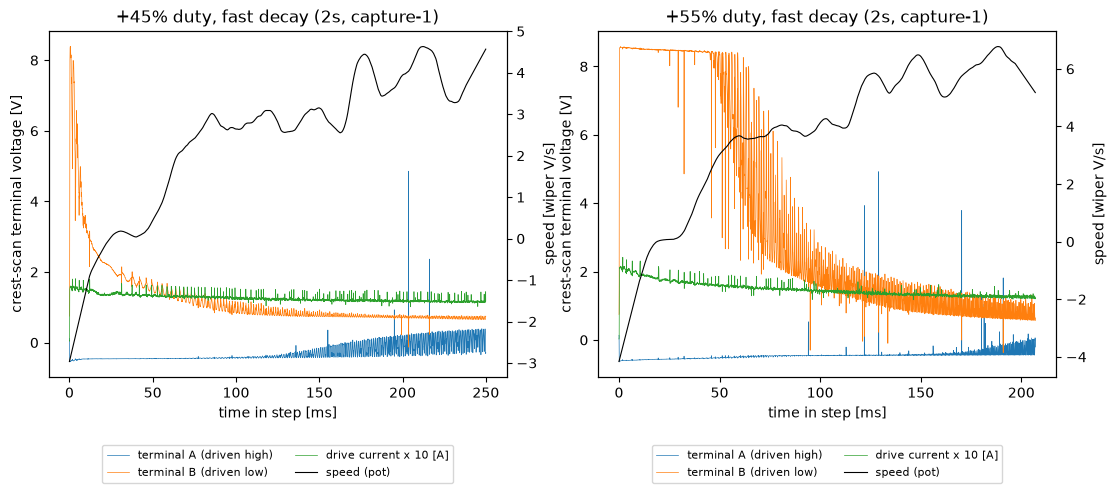

speed_Vps  terminal_B_V  terminal_A_V  drive_current_A
duty_pct quarter                                                        
45       1           -0.144         1.900        -0.458            0.136
         2            2.653         0.982        -0.433            0.125
         3            3.227         0.748        -0.260            0.118
         4            4.046         0.707         0.168            0.115
55       1            0.187         8.422        -0.558            0.171
         2            3.828         2.756        -0.462            0.148
         3            5.324         1.277        -0.446            0.135
         4            5.984         0.745        -0.397            0.127

In [6]:
name = next(iter(RECS[PRIMARY]))
df = RECS[PRIMARY][name]["fast"][0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, pct in zip(axes, [45, 55]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (board.tick_hz / 1000)
    p = seg["pos"].to_numpy() * board.v_adc_per_count
    speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / board.tick_hz)
    vA, vB = terms_V(seg)
    ax.plot(t, vA, lw=0.5, label="terminal A (driven high)")
    ax.plot(t, vB, lw=0.5, label="terminal B (driven low)")
    ax.plot(t, (seg["current_trough"] - seg["bias"]) * board.a_per_count * 10, lw=0.5,
            label="drive current x 10 [A]")
    ax.set_xlabel("time in step [ms]")
    ax.set_ylabel("crest-scan terminal voltage [V]")
    ax2 = ax.twinx()
    ax2.plot(t, speed, color="k", lw=0.8, label="speed (pot)")
    ax2.set_ylabel("speed [wiper V/s]")
    ax.set_title(f"+{pct}% duty, fast decay ({PRIMARY}, {name})")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=2, fontsize=8)
plt.show()

# Quarter-by-quarter means of the +45% and +55% steps, every capture of the
# primary campaign.
rows = []
for pct in (45, 55):
    for name, sweeps in RECS[PRIMARY].items():
        seg = sweeps["fast"][0]
        seg = seg[np.isclose(seg["duty_pct"], pct, atol=0.5)]
        p = seg["pos"].to_numpy() * board.v_adc_per_count
        speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / board.tick_hz)
        vA, vB = terms_V(seg)
        n = len(seg) // 4
        for q in range(4):
            sl = slice(q * n, (q + 1) * n)
            rows.append({
                "duty_pct": pct,
                "quarter": q + 1,
                "speed_Vps": speed[sl].mean(),
                "terminal_B_V": np.median(vB[sl]),
                "terminal_A_V": np.median(vA[sl]),
                "drive_current_A": (seg["current_trough"].iloc[sl].median()
                                    - seg["bias"].iloc[0]) * board.a_per_count,
            })
(pd.DataFrame(rows).groupby(["duty_pct", "quarter"])
   [["speed_Vps", "terminal_B_V", "terminal_A_V", "drive_current_A"]].mean().round(3))

The 2S data settles this more directly than the USB run could. Within the
55% step, terminal B starts at the full diode level of 8.42 V while the
motor is still at rest and the drive current is 0.171 A, and it falls to
2.76, 1.28 and 0.75 V over the four quarters as the motor spins up and the
drive current falls to 0.127 A. Within the 45% step the same collapse has
already happened before the first quarter ends: the medians are 1.90,
0.98, 0.75 and 0.71 V against speeds of -0.1, 2.7, 3.2 and 4.0 wiper V/s.
Terminal A, driven high, sits at the clamp of -0.46 V and comes off it as
the current falls, reaching +0.17 V in the last quarter of the 45% step.

So the reading tracks the drive current, not the speed. It falls as the
motor speeds up, which is the opposite of a back-EMF; it puts the terminal
driven low above the terminal driven high, the opposite polarity to the
coast segments of section 6.1; and it is present at 10% to 30% where the
motor does not move at all. It is a residue of the diode phase and carries
no speed information. *Hypothesis (not tested here): after the diode
current dies, the terminal that was held at rail plus one diode drop
discharges toward the bias through its divider and the capacitance of the
output node, and the scan catches it part way down, while a small
remaining current holds the other terminal at its body-diode clamp. The
reading is higher at higher duty and earlier in a step because a larger
current lengthens the diode phase and leaves less time for the discharge
before the fixed scan instant. The within-step collapse at 55%, where duty
is constant and only the current changes, is exactly that prediction.*

The consequence for the series is that the fast-decay crest scan delivers
no direct back-EMF sample at any duty in this scan geometry, on either
rail. Direct back-EMF is available from the coast segments of the
spin-down sweep (section 6.1), where the scan sits hundreds of
microseconds after the current has died.

### 5.4 Validity map

The map below records, for every bridge state and scan, the duty range in
which each channel reads a settled value of that state. The edges come
from the data of every capture of the primary campaign, on the 5% grid of
the sweeps, and are then assembled with the configured floors of section
2. The USB edge table prints next to it: it should agree wherever the edge
is a property of the scan geometry, and differ wherever the edge is a
property of the current, which is where the rail enters.

A driven terminal counts as settled when it reads within 0.1 V of the same
direction's light-load level (the 15% to 30% steps).

In [7]:
SETTLED_V = 0.1     # a driven terminal counts as settled within this of its light-load level
EMF_CLAMP_V = 1.1   # above this EMF the negative terminal is on its body-diode clamp

def edges(label, name):
    rail = RAILS[label][name]
    st, ft = SLOW[label][name], FAST[label][name]
    sweeps = RECS[label][name]
    fwd, rev = st[st["duty_pct"] > 0], st[st["duty_pct"] < 0]
    e = {"series": label, "capture": name}
    e["flag_from_pct"] = int(st[st["valid_frac"] > 0.5]["mag_pct"].min())
    for tab, key in [(fwd, "terminal_A_from_pct"), (rev, "terminal_B_from_pct")]:
        light = tab[(tab["mag_pct"] >= 15) & (tab["mag_pct"] <= 30)]["driven_terminal_V"].mean()
        e[key] = int(tab[tab["driven_terminal_V"] > light - SETTLED_V]["mag_pct"].min())
    def both_dirs(tab, cond):
        # Grid points where the condition holds in both directions.
        ok = tab[cond].groupby("mag_pct").size() == 2
        return set(ok[ok].index)
    def run_up_from(ok, start):
        # Last grid point of the contiguous run that starts at `start`.
        pct = start
        while pct + 5 in ok:
            pct += 5
        return pct
    ok = both_dirs(st, st["trough_offset_counts"].abs() <= 20)
    e["trough_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["crest_current_A"].abs() <= 10 * board.a_per_count)
    e["fast_crest_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["diode_frac"] >= 0.5)
    e["diode_phase_from_pct"] = min(ok)
    e["diode_phase_to_pct"] = run_up_from(ok, min(ok))
    e["rail_V"] = rail
    for tab, key in [(fwd, "lowside_R_B_ohm"), (rev, "lowside_R_A_ohm")]:
        ok = tab[(tab["mag_pct"] >= 20) & (tab["mag_pct"] <= 85)]
        e[key] = np.polyfit(ok["crest_current_A"], ok["lowside_terminal_V"], 1)[0]
    dl = ft[(ft["mag_pct"] >= e["diode_phase_from_pct"]) & (ft["mag_pct"] <= e["diode_phase_to_pct"])]
    e["diode_low_terminal_V"] = dl["low_terminal_V"].median()
    e["diode_high_terminal_V"] = dl["high_terminal_V"].median()
    # brake terminals, from the spin-down brake segments
    sp = sweeps["spindown"][0]
    br = sp[sp["kind"] == "brake"]
    vA, vB = terms_V(br)
    e["brake_terminal_max_V"] = max(np.quantile(vA, 0.99), np.quantile(vB, 0.99))
    e["brake_shunt_offset_counts"] = br["current_raw"].median() - sp["bias"].iloc[0]
    # coast, from the spin-down coast segments: the negative terminal once
    # the EMF is past the clamp threshold
    co_ = sp[sp["kind"] == "coast"]
    d = co_["dir"].to_numpy()
    vA, vB = terms_V(co_)
    emf = (vA - vB) * d
    e["coast_neg_terminal_clamp_V"] = np.median(np.where(d > 0, vB, vA)[emf > EMF_CLAMP_V])
    return e

edge_tab = pd.DataFrame([edges(label, name) for label in RECS for name in RECS[label]]
                        ).set_index(["series", "capture"])
edge_tab.round(3)

flag_from_pct  terminal_A_from_pct  terminal_B_from_pct  \
series capture                                                              
2s     capture-1             15                   10                   15   
       capture-2             15                   10                   15   
       capture-3             15                   10                   15   
       capture-4             15                   10                   15   
       capture-5             15                   10                   15   
usb    capture-1             15                   10                   15   
       capture-2             15                   10                   15   
       capture-3             15                   10                   15   
       capture-4             15                   10                   15   
       capture-5             15                   10                   15   

                  trough_bias_to_pct  fast_crest_bias_to_pct  \
series capture                                                 
2s     capture-1                  85                      50   
       capture-2                  85                      50   
       capture-3                  85                      55   
       capture-4                  85                      55   
       capture-5                  85                      55   
usb    capture-1                  75                      70   
       capture-2                  75                      70   
       capture-3                  75                      70   
       capture-4                  75                      70   
       capture-5                  70                      70   

                  diode_phase_from_pct  diode_phase_to_pct  rail_V  \
series capture                                                       
2s     capture-1                    65                  85   7.653   
       capture-2                    70                  85   7.608   
       capture-3                    65                  85   7.591   
       capture-4                    65                  85   7.576   
       capture-5                    65                  85   7.561   
usb    capture-1                    80                  85   4.621   
       capture-2                    80                  85   4.621   
       capture-3                    80                  85   4.622   
       capture-4                    80                  85   4.617   
       capture-5                    80                  85   4.620   

                  lowside_R_B_ohm  lowside_R_A_ohm  diode_low_terminal_V  \
series capture                                                             
2s     capture-1            0.531            0.534                 8.481   
       capture-2            0.531            0.560                 8.445   
       capture-3            0.532            0.561                 8.419   
       capture-4            0.529            0.551                 8.406   
       capture-5            0.556            0.557                 8.395   
usb    capture-1            0.531            0.588                 5.333   
       capture-2            0.529            0.609                 5.300   
       capture-3            0.523            0.579                 5.347   
       capture-4            0.519            0.618                 5.347   
       capture-5            0.552            0.594                 5.318   

                  diode_high_terminal_V  brake_terminal_max_V  \
series capture                                                  
2s     capture-1                 -0.501                 0.028   
       capture-2                 -0.507                 0.028   
       capture-3                 -0.500                 0.028   
       capture-4                 -0.500                 0.028   
       capture-5                 -0.498                 0.028   
usb    capture-1                 -0.519                 0.011   
       capture-2                 -0.523           

In [8]:
# Conservative over the captures of the PRIMARY campaign: latest lower edge,
# earliest upper edge.
prim = edge_tab.loc[PRIMARY]
def as_edges(s):
    return {k: (int(v) if k.endswith("_pct") else v) for k, v in s.items()}
lo = as_edges(prim.max())
hi = as_edges(prim.min())
mid = prim.mean()
rows = [
    ("drive", "slow", "crest", "shunt",
     f">= {board.floor_i_pct:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("drive", "slow", "crest", "driven terminal",
     f">= {board.floor_v_pct:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     "supply rail minus the high-side drop", "supply estimate"),
    ("drive", "slow", "crest", "low-side terminal",
     f">= {board.floor_v_pct:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     f"current times low-side on-resistance plus shunt, about {mid['lowside_R_A_ohm']:.2f} Ohm on A, "
     f"{mid['lowside_R_B_ohm']:.2f} Ohm on B, plus a fixed 40 mV offset between them", "switch drop"),
    ("drive", "fast", "trough", "shunt",
     f">= {board.floor_i_pct:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("brake", "slow", "trough", "shunt",
     f"<= {100 - board.floor_i_pct:.1f}", f"within 20 counts of bias to {hi['trough_bias_to_pct']}%",
     "bias plus a recovery offset growing with duty", "live bias tracker"),
    ("brake", "spin-down segment", "crest", "both terminals",
     "any", f"below {lo['brake_terminal_max_V']:.2f} V in all samples (tap near two thirds of VB)",
     "near ground, winding shorted through the low-side switches", "state check"),
    ("brake", "spin-down segment", "crest", "shunt",
     "any", f"offset {lo['brake_shunt_offset_counts']:.0f} counts",
     "bias, no current through the shunt", "bias"),
    ("coast", "fast", "crest", "shunt",
     f"<= {100 - board.floor_i_pct:.1f}", f"within 10 counts of bias to {hi['fast_crest_bias_to_pct']}%",
     "bias where the current has died, negative freewheel current in the diode phase", "bias, diode current"),
    ("coast", "fast", "crest", "terminals, diode phase",
     f"<= {100 - board.floor_v_pct:.1f}", f"sum above rail: {lo['diode_phase_from_pct']}% to {hi['diode_phase_to_pct']}%",
     f"rail plus one diode drop ({mid['diode_low_terminal_V'] - mid['rail_V']:.2f} V) on the terminal driven low, "
     f"{mid['diode_high_terminal_V']:.2f} V on the other",
     "phase discriminator only"),
    ("coast", "fast", "crest", "terminals, sum below rail",
     f"<= {100 - board.floor_v_pct:.1f}", f"5% to {lo['diode_phase_from_pct'] - 10}%, {lo['diode_phase_from_pct'] - 5}% mixed",
     "diode-phase residue on the terminal driven low, falling with the drive current, unrelated to speed", "none"),
    ("coast", "spin-down segment", "crest", "vA - vB",
     "any", "from the fourth sample after the drive ends, sum below rail",
     "direct back-EMF, each terminal on its own rest bias (section 6.1)", "speed"),
    ("coast", "spin-down segment", "crest", "negative terminal",
     "any", f"clamps at {mid['coast_neg_terminal_clamp_V']:.2f} V once the EMF passes about {EMF_CLAMP_V} V",
     "carries nearly the whole EMF below the clamp, then the positive terminal takes the rest (section 6.1)", "state check"),
    ("coast", "spin-down segment", "crest", "shunt",
     "any", "from the fourth sample after the drive ends",
     "bias, no current through the shunt", "bias"),
]
validity_map = pd.DataFrame(rows, columns=[
    "state", "decay or segment", "scan", "channel", "configured duty [%]",
    "measured range", "reads", "use in later notebooks"]).set_index(["state", "decay or segment", "scan", "channel"])
pd.set_option("display.max_colwidth", 100)
validity_map

configured duty [%]  \
state decay or segment  scan   channel                                         
drive slow              crest  shunt                                 >= 13.3   
                               driven terminal                       >= 13.3   
                               low-side terminal                     >= 13.3   
      fast              trough shunt                                 >= 13.3   
brake slow              trough shunt                                 <= 86.7   
      spin-down segment crest  both terminals                            any   
                               shunt                                     any   
coast fast              crest  shunt                                 <= 86.7   
                               terminals, diode phase                <= 86.7   
                               terminals, sum below rail             <= 86.7   
      spin-down segment crest  vA - vB                                   any   
                               negative terminal                         any   
                               shunt                                     any   

                                                                                                       measured range  \
state decay or segment  scan   channel                                                                                  
drive slow              crest  shunt                                                                    flag from 15%   
                               driven terminal                                                 A from 10%, B from 15%   
                               low-side terminal                                               A from 10%, B from 15%   
      fast              trough shunt                                                                    flag from 15%   
brake slow              trough shunt                                                  within 20 counts of bias to 85%   
      spin-down segment crest  both terminals                 below 0.03 V in all samples (tap near two thirds of VB)   
                               shunt                                                                  offset 5 counts   
coast fast              crest  shunt                                                  within 10 counts of bias to 50%   
                               terminals, diode phase                                      sum above rail: 70% to 85%   
                               terminals, sum below rail                                         5% to 60%, 65% mixed   
      spin-down segment crest  vA - vB                    from the fourth sample after the drive ends, sum below rail   
                               negative terminal                    clamps at -0.45 V once the EMF passes about 1.1 V   
                               shunt                                      from the fourth sample after the drive ends   

                                                                                                                                                        reads  \
state decay or segment  scan   channel                                                                                                                          
drive slow              crest  shunt                                                                                                  drive current plus bias   
                               driven terminal                                                                           supply rail minus the high-side drop   
                               low-side terminal          current times low-side on-resistance plus shunt, about 0.55 Ohm on A, 0.54 Ohm on B, plus a fixe...   
      fast              trough shunt                                                                                                  drive current plus bias   
brake slow              trough shunt                                      

The measured edges agree with the configured floors on the 5% grid in
every capture of the primary campaign. The USB edge table agrees on
everything that is a property of the scan geometry (the flag edge, the
terminal settling duty, the brake terminal levels) and differs on
everything that is a property of the current, exactly as it should:

- The diode phase starts at 65% to 70% on 2S and at 80% on USB, and ends at
  85% on both. The onset is where the freewheel current still lasts to the
  crest, which the higher rail reaches at a lower duty. The upper edge is
  where the OFF window runs out, which is scan geometry, so it does not
  move.
- The fast-decay coast shunt stays within 10 counts of the bias to 50-55%
  on 2S and to 70% on USB, the same effect from the other side.
- The brake-window trough shunt stays within 20 counts of the bias to 85%
  on 2S but only to 70-75% on USB, which is the wrong way round for a
  current effect and is section 9's first entry.

In corrected units, with each terminal taken as $r\,\text{tap} - (r - 1)
V_B$ on its own rest reading, the sum $v_A + v_B$ rests at $V_{B,A} +
V_{B,B}$ and exceeds the rail only in the diode phase, which is the
discriminator rule the later notebooks apply.

## 6. Spin-down

The spin-down sweep enters each coast or brake segment at the speed the
preceding 80 ms drive step reached. On 2S the entry speeds range from
about 3.2 to 9.9 wiper V/s and vary from step to step (section 3), so
coast and brake are compared through fitted models against measured speed,
never by pairing segments. On USB the same 20%, 30% and 40% steps enter at
1.6 to 6.5 wiper V/s, roughly half, which is the rail.

### 6.1 Terminal voltages during coast as direct back-EMF

During a coast segment the bridge is off, so once the winding current has
died the terminals carry the motor's back-EMF. The difference $v_A - v_B$,
each terminal on its own rest reading, reads the EMF directly, $e =
r\,(\text{tap}_A - \text{tap}_B)$ minus the rest split in ADC volts, taken
positive along the entry direction. Both terminals are readable. How the
EMF divides between the two terminals is a measured thing, and the table
further down shows it. The first three samples after the drive ends are
excluded (the diode phase appears in the second or third sample, with the
sum above the rail, and the third can catch the transition out of it), and
any later sample with the sum above the rail is excluded the same way.

The figure plots the EMF against the pot-derived speed for every coast
segment of every capture of the primary campaign. Both signals are
smoothed with the same 20 ms window. The second panel shows one coast
segment against time, with both terminals.

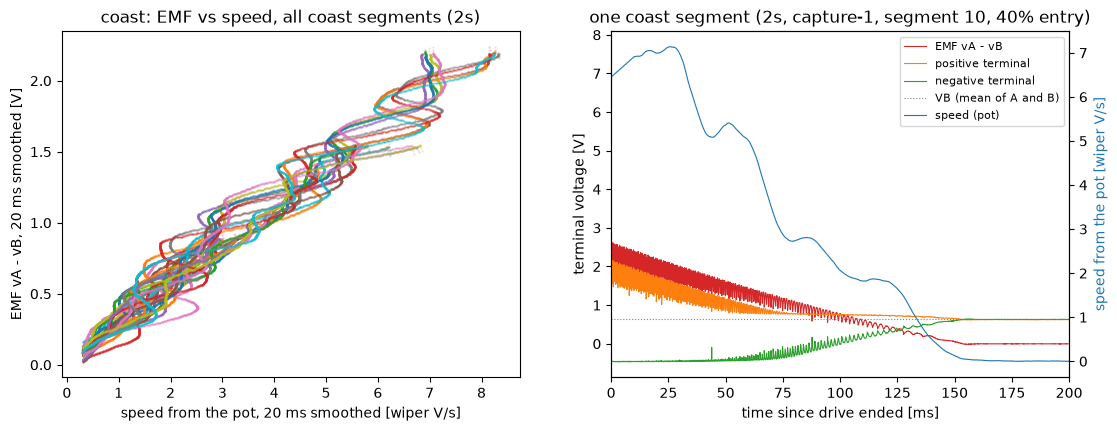

slope_regression_s                 intercept_V                  \
                     mean     min     max        mean     min     max   
series                                                                  
2s                 0.2690  0.2666  0.2708      0.0609  0.0469  0.0745   
usb                0.2308  0.2264  0.2343      0.0867  0.0708  0.1059   

       slope_integral_s                 segments          
                   mean     min     max     mean min max  
series                                                    
2s               0.2860  0.2816  0.2883      6.0   6   6  
usb              0.2822  0.2757  0.2871      6.0   6   6

In [9]:
SG_WIN = 401   # 20 ms smoothing window for speed from the pot

SKIP = 3       # samples excluded at the start of every coast segment

def coast_segments(sweeps):
    # Per coast segment: time, position (wiper V, positive along the entry
    # direction), EMF vA - vB (positive along the entry direction), the
    # positive and negative terminals and their sum, all in V. Each
    # terminal is corrected with its own rest bias.
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vA, vB = terms_V(seg)
        out.append({
            "seg": seg_id,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "t": np.arange(len(seg)) / board.tick_hz,
            "p": seg["pos"].to_numpy() * d * board.v_adc_per_count,
            "e": (vA - vB) * d,
            "pos_t": vA if d > 0 else vB,
            "neg_t": vB if d > 0 else vA,
            "sum": vA + vB,
            "shunt_offset": seg["current_raw"].to_numpy() - seg["bias"].iloc[0],
        })
    return out

def coast_mask(c, rail):
    i = np.arange(len(c["e"]))
    return (i >= SKIP) & (c["sum"] < rail)

COAST = {label: {name: coast_segments(sw) for name, sw in recs.items()}
         for label, recs in RECS.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in RECS[PRIMARY]:
    for c in COAST[PRIMARY][name]:
        v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / board.tick_hz)
        es = savgol_filter(c["e"], SG_WIN, 2)
        i = np.arange(len(v))
        m = (i >= SG_WIN // 2) & (v > 0.3) & coast_mask(c, RAILS[PRIMARY][name])
        axes[0].plot(v[m], es[m], ".", ms=1, alpha=0.3)
axes[0].set_xlabel("speed from the pot, 20 ms smoothed [wiper V/s]")
axes[0].set_ylabel("EMF vA - vB, 20 ms smoothed [V]")
axes[0].set_title(f"coast: EMF vs speed, all coast segments ({PRIMARY})")
name = next(iter(RECS[PRIMARY]))
c = COAST[PRIMARY][name][2]
v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / board.tick_hz)
axes[1].plot(c["t"] * 1e3, c["e"], lw=0.8, color="tab:red", label="EMF vA - vB")
axes[1].plot(c["t"] * 1e3, c["pos_t"], lw=0.8, color="tab:orange", label="positive terminal")
axes[1].plot(c["t"] * 1e3, c["neg_t"], lw=0.8, color="tab:green", label="negative terminal")
axes[1].axhline(REST_SUM[PRIMARY][name] / 2, color="grey", lw=0.8, ls=":",
                label="VB (mean of A and B)")
axes[1].set_xlabel("time since drive ended [ms]")
axes[1].set_ylabel("terminal voltage [V]")
ax2 = axes[1].twinx()
ax2.plot(c["t"] * 1e3, v, lw=0.8, color="tab:blue", label="speed (pot)")
ax2.set_ylabel("speed from the pot [wiper V/s]", color="tab:blue")
axes[1].set_xlim(0, 200)
axes[1].set_title(f"one coast segment ({PRIMARY}, {name}, segment {c['seg']}, {c['entry_pct']}% entry)")
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
plt.show()

rows = []
ratio_rows = []
for label in RECS:
    for name in RECS[label]:
        rail = RAILS[label][name]
        gv, ge = [], []
        integrals, travels = [], []
        for c in COAST[label][name]:
            v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / board.tick_hz)
            es = savgol_filter(c["e"], SG_WIN, 2)
            i = np.arange(len(v))
            m = (i >= SG_WIN // 2) & (v > 0.3) & coast_mask(c, rail)
            gv.append(v[m]); ge.append(es[m])
            # Ripple-immune route: the integral of the EMF over the segment
            # divided by the travel is the slope, if E = k v. The capture's
            # slope is the sum of the integrals over the sum of the travels,
            # so a segment counts in proportion to how far it moved.
            mm = coast_mask(c, rail)
            travel = np.median(c["p"][-1000:]) - np.median(c["p"][:3])
            integrals.append(np.sum(c["e"][mm]) / board.tick_hz)
            travels.append(travel)
            ratio_rows.append({"series": label, "capture": name, "entry_pct": c["entry_pct"],
                               "ratio": integrals[-1] / travel,
                               "travel_V": travel, "emf_peak_V": c["e"][mm].max()})
        k = np.polyfit(np.concatenate(gv), np.concatenate(ge), 1)
        rows.append({"series": label, "capture": name,
                     "slope_regression_s": k[0], "intercept_V": k[1],
                     "slope_integral_s": np.sum(integrals) / np.sum(travels),
                     "segments": len(travels)})
bemf_fit = pd.DataFrame(rows).set_index(["series", "capture"])
bemf_fit.groupby("series").agg(["mean", "min", "max"]).round(4)

The integral ratio per segment, grouped by the duty of the drive step that
set the entry speed, tests whether the slope depends on speed. The travel
and the peak EMF of each group say how far each segment moved and how high
its EMF got:

In [10]:
(pd.DataFrame(ratio_rows).groupby(["series", "entry_pct"])[["ratio", "travel_V", "emf_peak_V"]]
   .agg(["mean", "std", "min", "max"]).round(4))

ratio                         travel_V                  \
                    mean     std     min     max     mean     std     min   
series entry_pct                                                            
2s     20         0.3039  0.0216  0.2653  0.3307   0.1244  0.0120  0.1063   
       30         0.2726  0.0089  0.2581  0.2854   0.3548  0.0160  0.3352   
       40         0.2909  0.0076  0.2822  0.2995   0.6071  0.0317  0.5664   
usb    20         0.2931  0.0462  0.2414  0.3520   0.0487  0.0067  0.0403   
       30         0.3021  0.0191  0.2710  0.3313   0.1243  0.0082  0.1152   
       40         0.2721  0.0019  0.2691  0.2751   0.2598  0.0055  0.2498   

                         emf_peak_V                          
                     max       mean     std     min     max  
series entry_pct                                             
2s     20         0.1418     1.1158  0.0105  1.0980  1.1286  
       30         0.3827     1.8582  0.0271  1.8329  1.9315  
       40         0.6453     2.5844  0.0168  2.5627  2.6155  
usb    20         0.0564     0.5950  0.0090  0.5844  0.6116  
       30         0.1418     1.0226  0.0119  1.0043  1.0374  
       40         0.2667     1.4418  0.0166  1.4137  1.4672

The two terminals against the EMF level, pooled over every coast segment
of every capture and masked like the fits. This is where the EMF split
between the terminals is measured:

In [11]:
# Both terminals against the EMF level, pooled over every coast segment of
# every capture, masked like the fits. Bins of 0.2 V.
rows = []
for label in RECS:
    for name in RECS[label]:
        for c in COAST[label][name]:
            m = coast_mask(c, RAILS[label][name])
            rows.append(pd.DataFrame({"series": label, "e": c["e"][m], "pos_t": c["pos_t"][m],
                                      "neg_t": c["neg_t"][m], "sum": c["sum"][m]}))
tt = pd.concat(rows)
tt["EMF bin [V]"] = (np.floor(tt["e"] / 0.2) * 0.2).round(1)
(tt.groupby(["series", "EMF bin [V]"])[["pos_t", "neg_t", "sum"]]
   .median().rename(columns={"pos_t": "positive terminal [V]", "neg_t": "negative terminal [V]",
                             "sum": "sum vA + vB [V]"})
   .assign(samples=tt.groupby(["series", "EMF bin [V]"]).size()).round(3))

positive terminal [V]  negative terminal [V]  \
series EMF bin [V]                                                 
2s     -0.2                         0.624                  0.628   
        0.0                         0.628                  0.624   
        0.2                         0.713                  0.417   
        0.4                         0.736                  0.237   
        0.6                         0.751                  0.055   
        0.8                         0.766                 -0.130   
        1.0                         0.777                 -0.312   
        1.2                         0.882                 -0.416   
        1.4                         1.049                 -0.446   
        1.6                         1.228                 -0.463   
        1.8                         1.419                 -0.475   
        2.0                         1.616                 -0.480   
        2.2                         1.809                 -0.485   
        2.4                         1.993                 -0.467   
        2.6                         2.147                 -0.461   
usb    -0.2                         0.627                  0.630   
        0.0                         0.630                  0.627   
        0.2                         0.721                  0.422   
        0.4                         0.743                  0.253   
        0.6                         0.761                  0.065   
        0.8                         0.773                 -0.117   
        1.0                         0.785                 -0.305   
        1.2                         0.864                 -0.418   
        1.4                         0.975                 -0.440   

                    sum vA + vB [V]  samples  
series EMF bin [V]                            
2s     -0.2                   1.254    85834  
        0.0                   1.252    92194  
        0.2                   1.131     9912  
        0.4                   0.973     9290  
        0.6                   0.808     8444  
        0.8                   0.635     7945  
        1.0                   0.465     6155  
        1.2                   0.463     5212  
        1.4                   0.601     4658  
        1.6                   0.771     3659  
        1.8                   0.951     2531  
        2.0                   1.146     1937  
        2.2                   1.333     1362  
        2.4                   1.516      773  
        2.6                   1.686        2  
usb    -0.2                   1.257    96498  
        0.0                   1.257   105276  
        0.2                   1.143    11832  
        0.4                   0.996     9844  
        0.6                   0.825     6355  
        0.8                   0.656     5241  
        1.0                   0.480     2924  
        1.2                   0.448     1750  
        1.4                   0.537      189

Findings:

- **The number.** On 2S the EMF follows the speed with a slope of **0.286 V
  per wiper V/s** from the travel-weighted integral ratio (0.282 to 0.288
  across the five captures). That is the coast back-EMF slope this notebook
  hands on. The regression against pot speed gives 0.269 (0.267 to 0.271)
  with an intercept of 0.06 V. The regression is the weaker of the two: the
  pot ripple is noise on its speed axis, and noise on the x axis of a
  straight-line fit pulls the slope down and pushes the intercept up. The
  integral ratio has no speed axis.
- **The cross-check passes.** USB gives an integral ratio of 0.282 (0.276
  to 0.287), 1.3% below the 2S value. The slope is a property of the motor
  and the gear train as seen through the pot, with no rail in it, so the
  two campaigns should agree, and they do to within their own
  capture-to-capture spread. The regression route does not: it gives 0.231
  on USB, 18% below its own integral ratio, against a 6% gap on 2S. That is
  the x-axis-noise bias again, and it is worse on USB because the speed
  range is half as wide. It is the clearest single reason not to fit
  anything on the low rail.
- The registry carries `coast_bemf_slope_measured` = 0.197 [0.19, 0.204]
  from the retired chain, whose taps returned to ground. That entry is
  superseded by the 0.286 measured here on the biased taps, and the caveat
  attached to it says as much.
- By entry duty on 2S, the integral ratio is 0.273 for the 30% entries with
  a standard deviation of 0.009 over the ten segments, and 0.291 with a
  standard deviation of 0.008 for the 40% entries. The 20% entries read
  0.304 with a standard deviation of 0.022. Their travel is 0.124 wiper V,
  two or three periods of the pot ripple below, so the denominator of the
  ratio is still at the mercy of where in the ripple the segment starts and
  ends; the 30% and 40% entries travel 0.355 and 0.607 V. The
  travel-weighted ratio lets the long segments dominate. The residual
  spread between the 30% and 40% groups, 6% with tight standard deviations
  inside each, is section 9's fifth entry.
- **The EMF split between the terminals changes at the clamp.** Below about
  1.1 V of EMF the negative terminal carries nearly the whole of it: it
  falls about 1 V per volt of EMF, from the bias at rest to -0.31 V in the
  1.0 V bin, while the positive terminal rises only 0.15 V over the same
  range and the sum falls. From the 1.2 V bin the negative terminal
  flattens at -0.42 V and then -0.48 V, its body-diode clamp, and the
  positive terminal takes over: it climbs from 0.88 V to 1.99 V through the
  2.4 V bin while the sum climbs with it. The USB run only just reaches the
  clamp (its highest bin is 1.4 V), which is why the earlier version of
  this notebook could describe the split as asymmetric and stop there. The
  split below the clamp is still not the symmetric one two equal dividers
  to one bias node would give. *Hypothesis (not tested here): some path in
  the gate driver, the bootstrap charging circuit being one candidate,
  holds the terminal that was driven high near the bias until the other one
  clamps.* The EMF is the terminal difference and does not depend on the
  split, on either side of the clamp.
- The EMF decays smoothly through the segment, with a ripple of its own of
  about 10% rms at a period much shorter than the pot's. The pot-derived
  speed rides on a ripple of 10 to 30% rms with a period of roughly 0.05 V
  of wiper travel, visible in the right panel and as the loops in the left
  panel. That ripple is absent from the EMF, so it is on the pot side of
  the gear train. *Hypothesis (not tested here): the ripple is a periodic
  error of the potentiometer track or of the final gear stage. Notebook 06
  takes it up.*
- The terminal difference removes the divider bias and the split, so
  neither the load of the dividers nor the clamp enters the slope.
  Notebook 03 compares this slope with the drive-side estimate. The
  motor-shaft constant needs the gear ratio (notebook 06).

The slope from the travel-weighted integral ratio, on the primary
campaign, is the one used below to convert EMF volts into wiper V/s.

### 6.2 Coast deceleration vs speed

The model is Coulomb plus viscous friction,

$$\frac{dv}{dt} = -(a + b\,v), \qquad v > 0,$$

with $a$ in wiper V/s$^2$ and $b$ in 1/s. Two routes fit it. The pot route
fits the closed-form trajectory $p(t)$ of the model to the position trace
of every coast segment of a capture jointly, with one $(a, b)$ per capture
and one entry speed per segment. The terminal route fits the same model to
the EMF $e(t)$ of the same segments, where $e$ stands in for speed, and
converts $a$ with the slope of section 6.1. The terminal route gives $b$
directly, since $b$ is a rate and needs no unit conversion. The figure
shows the measured speed of every coast segment of the primary campaign
with the terminal-route model overlaid.

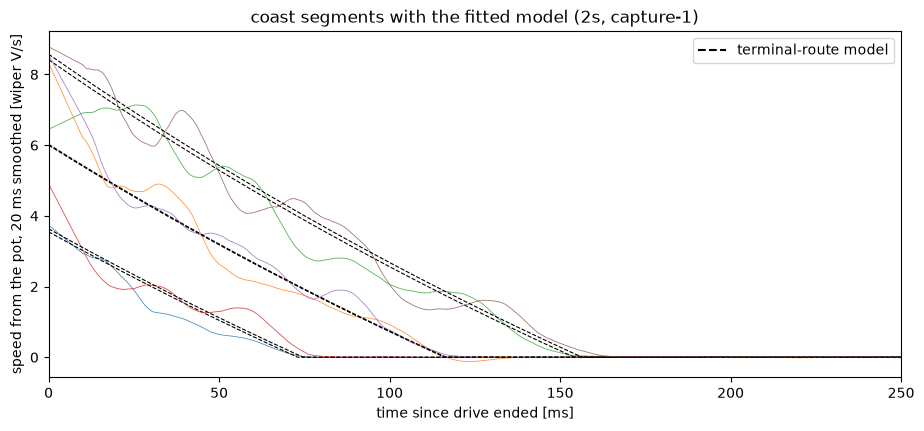

pot route a [V/s2]               pot route b [1/s]               \
                     mean    min    max              mean   min    max   
series                                                                   
2s                  36.75  34.06  38.51              4.43  3.93   5.04   
usb                 23.58  18.60  26.73             10.11  7.89  12.61   

       pot route rms resid [mV]             terminal route a [V/s2]  ...  \
                           mean   min   max                    mean  ...   
series                                                               ...   
2s                         3.12  3.00  3.23                   41.16  ...   
usb                        2.48  2.12  2.85                   32.18  ...   

              terminal route b [1/s]             terminal route b se [1/s]  \
          max                   mean   min   max                      mean   
series                                                                       
2s      43.86                   2.76  2.63  2.89                      0.04   
usb     34.42                   4.18  3.91  4.57                      0.06   

                   terminal route rms resid [mV]                
         min   max                          mean    min    max  
series                                                          
2s      0.04  0.04                         63.71  61.74  64.80  
usb     0.06  0.06                         29.75  29.10  30.29  

[2 rows x 21 columns]

In [12]:
FIT_N = 5000   # 250 ms of every zero-duty segment enters the fit

def traj(t, p0, v0, a, b):
    # Position under dv/dt = -(a + b v) from v0, at rest after t_stop.
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    tt = np.minimum(t, t_stop)
    return p0 + (v0 + a / b) * (1 - np.exp(-b * tt)) / b - (a / b) * tt

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def joint_fit(segs, signal, mask_fn, has_p0):
    # Shared (a, b), per-segment start value (and offset when has_p0).
    t = np.arange(FIT_N) / board.tick_hz
    per = 2 if has_p0 else 1
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            y = c[signal][:FIT_N]
            m = mask_fn(c)[:FIT_N]
            if has_p0:
                model = traj(t, x[2 + per * i], x[3 + per * i], x[0], x[1])
            else:
                model = speed_model(t, x[2 + i], x[0], x[1])
            r.append((model - y)[m])
        return np.concatenate(r)
    x0 = [30.0, 5.0]
    lb = [0.0, 0.0]
    for c in segs:
        y = c[signal]
        if has_p0:
            x0 += [y[0], 5.0]
            lb += [-np.inf, 0.0]
        else:
            x0 += [max(y[3], 0.1)]
            lb += [0.0]
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    se = np.sqrt(np.diag(cov))
    starts = res.x[3::2] if has_p0 else res.x[2:]
    return {"a": res.x[0], "b": res.x[1], "a_se": se[0], "b_se": se[1],
            "starts": starts, "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

coast_fits = {}
for label in RECS:
    for name in RECS[label]:
        segs = COAST[label][name]
        rail = RAILS[label][name]
        slope = bemf_fit.loc[(label, name), "slope_integral_s"]
        pot = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
        term = joint_fit(segs, "e", lambda c: coast_mask(c, rail), False)
        coast_fits[(label, name)] = {"segs": segs, "pot": pot, "term": term, "slope": slope}

fig, ax = plt.subplots(figsize=(11, 4.5))
name = next(iter(RECS[PRIMARY]))
f = coast_fits[(PRIMARY, name)]
t = np.arange(FIT_N) / board.tick_hz
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], SG_WIN, 2, deriv=1, delta=1 / board.tick_hz)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    vm = speed_model(t, f["term"]["starts"][i], f["term"]["a"], f["term"]["b"]) / f["slope"]
    ax.plot(t * 1e3, vm, "k--", lw=0.8)
ax.plot([], [], "k--", label="terminal-route model")
ax.set_xlim(0, 250)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 20 ms smoothed [wiper V/s]")
ax.set_title(f"coast segments with the fitted model ({PRIMARY}, {name})")
ax.legend()
plt.show()

rows = []
for (label, name), f in coast_fits.items():
    rows.append({
        "series": label,
        "capture": name,
        "pot route a [V/s2]": f["pot"]["a"],
        "pot route b [1/s]": f["pot"]["b"],
        "pot route rms resid [mV]": f["pot"]["rms_resid"] * 1e3,
        "terminal route a [V/s2]": f["term"]["a"] / f["slope"],
        "terminal route b [1/s]": f["term"]["b"],
        "terminal route b se [1/s]": f["term"]["b_se"],
        "terminal route rms resid [mV]": f["term"]["rms_resid"] * 1e3,
    })
coast_tab = pd.DataFrame(rows).set_index(["series", "capture"])
coast_tab.groupby("series").agg(["mean", "min", "max"]).round(2)

Findings:

- **The numbers.** On 2S the terminal route puts the Coulomb term at
  **41.2 wiper V/s$^2$** (40.2 to 43.9 across captures) and the viscous
  term at **2.76 1/s** (2.63 to 2.89). The standard error on $b$ from the
  fit is 0.04 1/s, an optimistic figure, since the 64 mV rms residual is
  dominated by the EMF ripple, which is correlated from sample to sample.
  At the highest entry speed of about 8.6 wiper V/s the viscous term
  contributes 24 wiper V/s$^2$, well under the Coulomb term, so the model
  curves in the figure are close to straight lines.
- The pot route on 2S puts the Coulomb term at 36.8 wiper V/s$^2$ (34.1 to
  38.5) and $b$ at 4.43 1/s (3.93 to 5.04). The two routes disagree on the
  split and agree on the total: at 3 wiper V/s they give 49.4 and 50.0
  wiper V/s$^2$, 1.2% apart. This is better than the earlier USB-only
  version of this notebook managed, where the pot route drove $b$ to
  0.6 1/s and could not resolve the split at all, and the reason is the
  speed range: the 2S segments start twice as fast and travel five times
  as far, so there is real curvature for the fit to find.
- **The cross-check does not fully pass, and that is worth saying.** USB
  gives 32.2 wiper V/s$^2$ and 4.18 1/s by the terminal route. Friction has
  no rail in it, so the split should not move with the supply, and it does:
  $a$ is 22% lower and $b$ is 51% higher on USB. The totals agree much
  better where both campaigns have data, 49.4 against 44.7 wiper V/s$^2$ at
  3 wiper V/s (10%) and 53.6 against 51.0 at 4.5 wiper V/s (5%). What each
  campaign has is a different speed range: 3.5 to 8.6 wiper V/s on 2S, 1.8
  to 4.9 on USB. Section 9 has the candidates and the experiment.
- Section 6.4 tests the 2S terminal-route parameters against the measured
  stopping distances, which the pot measures without ripple sensitivity.

### 6.3 Brake deceleration vs speed

In brake the winding is shorted through the low-side switches. The
back-EMF drives a current through the winding resistance and the switch
on-resistance, and the resulting torque opposes the motion in proportion
to speed, so the same model applies with a much larger $b$. The terminals
are within 0.03 V of ground during brake (section 5.4), so no EMF is
readable and only the pot route is available. The friction is the same
mechanism as in coast, so the fit first holds $a$ at the terminal-route
coast value of the same capture and fits $b$ and the entry speeds, then
repeats with $a$ free as a check.

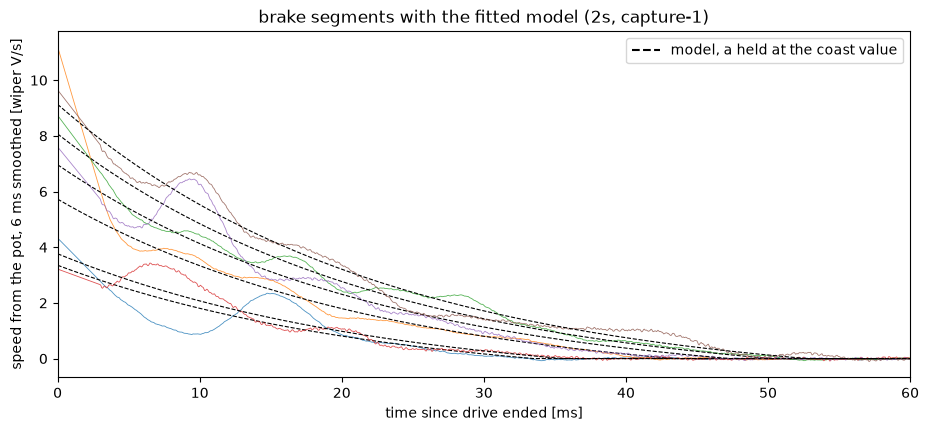

a held [V/s2]               b, a held [1/s]               b se [1/s]  \
                mean    min    max            mean    min    max       mean   
series                                                                        
2s             41.16  40.15  43.86           48.12  43.94  49.56       0.09   
usb            32.18  30.57  34.42           45.70  35.68  53.09       0.17   

                   rms resid, a held [mV]  ... a free [V/s2] b, a free [1/s]  \
         min   max                   mean  ...           max            mean   
series                                     ...                                 
2s      0.08  0.10                   1.44  ...         51.92           47.66   
usb     0.15  0.17                   1.53  ...        106.61           12.58   

                     rms resid, a free [mV]            brake/coast b ratio  \
          min    max                   mean  min   max                mean   
series                                                                       
2s      40.74  54.24                   1.43  1.3  1.63               17.44   
usb      0.00  52.84                   1.44  1.4  1.49               10.99   

                      
          min    max  
series                
2s      16.00  18.74  
usb      7.81  12.25  

[2 rows x 24 columns]

In [13]:
def brake_segments(sweeps):
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "brake"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vA, vB = terms_V(seg)
        out.append({
            "seg": seg_id,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "t": np.arange(len(seg)) / board.tick_hz,
            "p": seg["pos"].to_numpy() * d * board.v_adc_per_count,
            "vA": vA,
            "vB": vB,
        })
    return out

def brake_fit_fixed_a(segs, a_fixed):
    t = np.arange(FIT_N) / board.tick_hz
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            r.append(traj(t, x[1 + 2 * i], x[2 + 2 * i], a_fixed, x[0]) - c["p"][:FIT_N])
        return np.concatenate(r)
    x0 = [40.0] + sum([[c["p"][0], 5.0] for c in segs], [])
    lb = [0.0] + sum([[-np.inf, 0.0] for _ in segs], [])
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    return {"b": res.x[0], "b_se": np.sqrt(cov[0, 0]), "starts": res.x[2::2],
            "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

brake_fits = {}
for label in RECS:
    for name, sweeps in RECS[label].items():
        segs = brake_segments(sweeps)
        cf = coast_fits[(label, name)]
        a_coast = cf["term"]["a"] / cf["slope"]
        fixed = brake_fit_fixed_a(segs, a_coast)
        free = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
        brake_fits[(label, name)] = {"segs": segs, "fixed": fixed, "free": free,
                                     "a_coast": a_coast}

fig, ax = plt.subplots(figsize=(11, 4.5))
name = next(iter(RECS[PRIMARY]))
f = brake_fits[(PRIMARY, name)]
t = np.arange(FIT_N) / board.tick_hz
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], 121, 2, deriv=1, delta=1 / board.tick_hz)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    ax.plot(t * 1e3, speed_model(t, f["fixed"]["starts"][i], f["a_coast"], f["fixed"]["b"]),
            "k--", lw=0.8)
ax.plot([], [], "k--", label="model, a held at the coast value")
ax.set_xlim(0, 60)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 6 ms smoothed [wiper V/s]")
ax.set_title(f"brake segments with the fitted model ({PRIMARY}, {name})")
ax.legend()
plt.show()

rows = []
for (label, name), f in brake_fits.items():
    b_coast = coast_fits[(label, name)]["term"]["b"]
    rows.append({
        "series": label,
        "capture": name,
        "a held [V/s2]": f["a_coast"],
        "b, a held [1/s]": f["fixed"]["b"],
        "b se [1/s]": f["fixed"]["b_se"],
        "rms resid, a held [mV]": f["fixed"]["rms_resid"] * 1e3,
        "a free [V/s2]": f["free"]["a"],
        "b, a free [1/s]": f["free"]["b"],
        "rms resid, a free [mV]": f["free"]["rms_resid"] * 1e3,
        "brake/coast b ratio": f["fixed"]["b"] / b_coast,
    })
brake_tab = pd.DataFrame(rows).set_index(["series", "capture"])
brake_tab.groupby("series").agg(["mean", "min", "max"]).round(2)

Findings:

- **The number.** With $a$ held at the coast value, the 2S brake viscous
  term is **48.1 1/s** (43.9 to 49.6 across captures), 16 to 19 times the
  coast value. The winding short adds electrical damping of that size on
  top of the mechanical friction.
- The cross-check passes on the damping and not on the ratio. USB gives
  45.7 1/s (35.7 to 53.1), 5% below 2S and inside its own spread, which is
  what a quantity with no rail in it should do. The ratio to the coast $b$
  is 11 on USB against 17 on 2S, but that is the coast $b$ moving, not the
  brake one, and it is the same open item as section 6.2.
- Freeing $a$ is a much weaker test on USB than on 2S. On 2S the free fit
  lands at $a$ = 42.4 wiper V/s$^2$ and $b$ = 47.7 1/s, within a few
  percent of the held-$a$ answer, with no change in residual. On USB it
  runs away to $a$ = 86.7 (32 to 107) and $b$ = 12.6 (0 to 53) with the
  same residual: the two terms trade freely against each other. The pot
  ripple sets this limit and the brake segments are short (25 to 53 ms),
  so the higher entry speeds of 2S are what make the free fit behave.
- The model misses the first few milliseconds of the fastest entries,
  where the measured speed drops faster than the fitted exponential. The
  ripple period at those speeds is close to the fit's time scale, so
  whether this is a real departure from the linear model is left open.

### 6.4 Stopping distance vs entry speed

For the fitted model the stopping distance from entry speed $v_0$ is

$$d(v_0) = \frac{v_0}{b} - \frac{a}{b^2}\ln\!\left(1 + \frac{b\,v_0}{a}\right).$$

The measured stopping distance of each zero-duty segment is the settled
position (median of the last 50 ms) minus the position at entry. The entry
speed comes from the fits above (the terminal route for coast, the held-a
fit for brake). The figure compares measured distances with the model
curve for both states on the primary campaign, which is a check of the
fitted parameters against a quantity the pot measures without ripple
sensitivity.

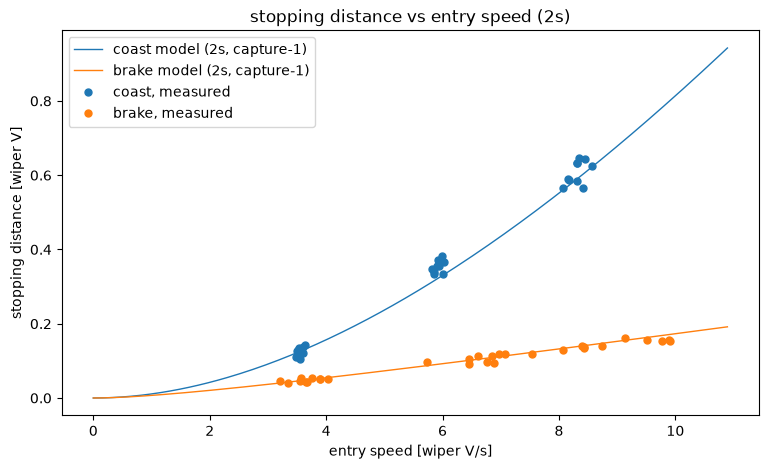

series               2s                                               usb  \
state             brake                   coast                     brake   
entry_pct            20      30      40      20       30       40      20   
entry_Vps  min    3.206   5.727   8.070   3.478    5.811    8.069   1.583   
           max    4.024   7.542   9.904   3.635    6.024    8.573   2.530   
           mean   3.659   6.734   9.027   3.545    5.923    8.310   1.954   
measured_V min    0.041   0.091   0.128   0.106    0.335    0.566   0.022   
           max    0.054   0.119   0.162   0.142    0.383    0.645   0.030   
           mean   0.048   0.107   0.146   0.124    0.355    0.607   0.025   
model_V    min    0.038   0.087   0.130   0.125    0.330    0.592   0.016   
           max    0.053   0.114   0.158   0.138    0.349    0.637   0.029   
           mean   0.046   0.101   0.144   0.132    0.339    0.618   0.022   
error_pct  min  -16.357 -11.747  -5.857  -7.571   -8.937   -1.954 -28.730   
           max    7.450   7.367   4.242  18.166    0.444    6.507   5.650   
           mean  -3.075  -4.630  -1.585   7.008   -4.355    1.918 -10.613   
stop_ms    min   32.144  43.419  48.993  73.059  116.134  154.164  24.879   
           max   36.486  47.257  52.741  79.636  123.869  163.938  31.901   
           mean  34.546  45.328  50.820  77.312  121.220  160.520  29.010   

series                                                    
state                             coast                   
entry_pct            30      40      20      30       40  
entry_Vps  min    2.947   4.723   1.834   3.188    4.595  
           max    4.164   6.538   2.040   3.448    4.909  
           mean   3.474   5.786   1.940   3.313    4.749  
measured_V min    0.043   0.077   0.040   0.115    0.250  
           max    0.054   0.097   0.056   0.142    0.267  
           mean   0.049   0.085   0.049   0.124    0.260  
model_V    min    0.045   0.087   0.045   0.125    0.242  
           max    0.055   0.096   0.055   0.143    0.264  
           mean   0.049   0.092   0.050   0.133    0.251  
error_pct  min   -8.877  -5.689  -6.852   0.653   -6.008  
           max    8.261  15.846  16.621  18.210   -0.614  
           mean  -0.754   8.262   4.330   7.634   -3.354  
stop_ms    min   36.306  46.117  50.042  82.181  110.938  
           max   42.664  53.127  57.351  88.927  117.605  
           mean  38.997  48.680  53.794  85.647  114.953

In [14]:
def stop_dist(v0, a, b):
    return v0 / b - a / b ** 2 * np.log1p(b * v0 / a)

rows = []
for label in RECS:
    for name in RECS[label]:
        cf, bf = coast_fits[(label, name)], brake_fits[(label, name)]
        for i, c in enumerate(cf["segs"]):
            v0 = cf["term"]["starts"][i] / cf["slope"]
            a, b = cf["term"]["a"] / cf["slope"], cf["term"]["b"]
            rows.append({"series": label, "capture": name, "state": "coast",
                         "entry_pct": c["entry_pct"], "entry_Vps": v0,
                         "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                         "model_V": stop_dist(v0, a, b),
                         "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
        for i, c in enumerate(bf["segs"]):
            v0 = bf["fixed"]["starts"][i]
            a, b = bf["a_coast"], bf["fixed"]["b"]
            rows.append({"series": label, "capture": name, "state": "brake",
                         "entry_pct": c["entry_pct"], "entry_Vps": v0,
                         "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                         "model_V": stop_dist(v0, a, b),
                         "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
sd = pd.DataFrame(rows)
sd["error_pct"] = (sd["model_V"] / sd["measured_V"] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
name = next(iter(RECS[PRIMARY]))
cf, bf = coast_fits[(PRIMARY, name)], brake_fits[(PRIMARY, name)]
vv = np.linspace(0, sd[sd["series"] == PRIMARY]["entry_Vps"].max() * 1.1, 200)
ax.plot(vv, stop_dist(vv, cf["term"]["a"] / cf["slope"], cf["term"]["b"]), "-",
        color="tab:blue", lw=1, label=f"coast model ({PRIMARY}, {name})")
ax.plot(vv, stop_dist(vv, bf["a_coast"], bf["fixed"]["b"]), "-",
        color="tab:orange", lw=1, label=f"brake model ({PRIMARY}, {name})")
for state, color in [("coast", "tab:blue"), ("brake", "tab:orange")]:
    g = sd[(sd["state"] == state) & (sd["series"] == PRIMARY)]
    ax.plot(g["entry_Vps"], g["measured_V"], "o", color=color, ms=5, label=f"{state}, measured")
ax.set_xlabel("entry speed [wiper V/s]")
ax.set_ylabel("stopping distance [wiper V]")
ax.set_title(f"stopping distance vs entry speed ({PRIMARY})")
ax.legend()
plt.show()

(sd.groupby(["series", "state", "entry_pct"])
   [["entry_Vps", "measured_V", "model_V", "error_pct", "stop_ms"]]
   .agg(["min", "max", "mean"]).round(3).T)

Findings:

- On 2S, coast stopping distances range from 0.11 to 0.65 wiper V for entry
  speeds of 3.5 to 8.6 wiper V/s, with stop times of 73 to 164 ms. The
  terminal-route model matches the measured distances to a mean error of
  +7.0% at the 20% entries, -4.4% at the 30% entries and +1.9% at the 40%
  entries, worst case +18% on one 20% segment. The agreement at the 30% and
  40% entries, where the travel is many ripple periods, supports the split
  between the Coulomb and viscous terms.
- The residual pattern is the same shape as before but half the size: the
  model over-predicts at the shortest entries, where the travel is smallest
  and the Coulomb term dominates. A model that stops too late at low speed
  has its Coulomb term a little low, so the split still leans slightly too
  far toward viscous near rest. Notebook 04 takes that up.
- Brake stopping distances are three to four times shorter at the same
  entry speed, 0.04 to 0.16 wiper V, with stop times of 32 to 53 ms. The
  held-$a$ model matches them to within 5% in the mean at every entry duty,
  worst case -16%, the scatter the pot ripple leaves on segments this
  short.
- The USB rows of the same table are the cross-check and they behave the
  same way at half the entry speed, with mean errors between -11% and +8%
  and a worst case of -29% at its 20% entries, where the travel is 0.05
  wiper V, about one ripple period. That is the low-rail limit of this
  measurement, not a different mechanism.

## 7. Limitations and open issues

- **One unit, one board.** All numbers describe this one servo and this
  one board. The gear train has prior wear.
- **The board is a hacked rig.** Section 1 describes it, and its registry
  entry prints in section 2. The bus telemetry stream couples into the
  current amplifier output on this board. It is flat within about a count
  at rest on this firmware build (notebook 00, section 5.2), but it is a
  limitation of the board, and I leave it as one. The next board revision
  does not have it, and nothing in this notebook is written to dodge it.
- **Rail-dependent numbers.** The speeds, the travel, the EMF magnitudes,
  the freewheel current, the fast-decay motion threshold, the duty at
  which the diode phase starts and how far the floating terminals get
  toward their clamps all scale with the rail, and they are all smaller on
  USB. The slopes, the on-resistances, the friction terms and the brake
  damping should not depend on it; the coast friction split does anyway
  (section 9).
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per sweep and per terminal, 0.627 V on A and 0.630 V on B
  against a 0.628 V nominal, so the absolute terminal voltages inherit
  only the VDD scaling. The nominal bias divider itself is a design value
  with unmeasured tolerance.
- **The two terminals do not read alike.** Their rest readings differ by
  four counts (notebook 00, section 5.3), and after each is corrected with
  its own rest reading they still differ by about 60 mV when driven and
  40 mV on the low side (section 5.2). Using each terminal's own rest
  reading is the whole treatment here. The cause is open (section 9).
- **Coast from high speed is still absent.** The schedule stops at 40%
  duty. On 2S the 40% entry reaches 8.6 wiper V/s, well under the 19.3
  wiper V/s top speed of notebook 00, so the coast model is fitted below
  that and extrapolated above. A spin-down capture with 60% and 80%
  entries would fix that, and it is what several entries in section 9 ask
  for.
- **Entry speeds vary.** Each drive step starts with residual motion from
  the repositioning move, so the entry speeds are measured, never
  commanded, and the spin-down segments do not pair up.
- **The pot speed ripple.** The pot-derived speed carries a ripple of 10
  to 30% rms that the EMF does not show (section 6.1). Every fit that uses
  the pot alone is limited by it, in particular the brake fits of section
  6.3 and the shortest segments everywhere.
- **The clamp and diode levels are measured levels.** The diode-phase
  levels (rail plus 0.83 V on one terminal, -0.50 V on the other) are read
  from this driver at these currents. In coast the negative terminal
  carries nearly the whole EMF until it reaches its body-diode clamp near
  -0.45 V, above which the positive terminal takes the rest (section 6.1);
  the asymmetry below the clamp is a hypothesis. They enter the validity
  map as state checks. The EMF is independent of them, since it is the
  terminal difference.
- **OFF-state shunt samples sit a few counts above the baseline.** The
  trough scan under slow decay, the crest scan under fast decay, and the
  spin-down brake and coast segments all read 3 to 5 counts above the
  bridge-disabled baseline (section 5.2), and the trough offset then grows
  with duty. Both are open.
- **The sampling floors are this board's** and the registry still marks
  them unverified against the flashed firmware.

## 8. What the next notebooks use from here

- The validity map of section 5.4, as the gate on every current and
  terminal sample by bridge state, decay mode and scan.
- The tap formula of section 2, $V_t = r\,\text{tap} - (r - 1) V_B$ with
  $V_B$ read from the baseline of each sweep for each terminal
  separately, for every absolute terminal voltage, and the difference
  $v_A - v_B$ on the same per-terminal correction for the EMF.
- The rail, the diode level and the discriminator threshold of section
  5.3, all in corrected terminal volts, for separating the diode phase
  from the settled coast window, with the sum's rest level at
  $V_{B,A} + V_{B,B}$.
- The coast EMF $v_A - v_B$ as a direct speed signal with the slope of
  section 6.1, **0.286 V per wiper V/s** measured on 2S, and the fact that
  the pot ripple is absent from it.
- The coast friction model of section 6.2 (Coulomb 41.2 wiper V/s$^2$ and
  viscous 2.76 1/s by the terminal route on 2S, with the pot route
  agreeing on the total to 1.2% at 3 wiper V/s) and the brake damping of
  section 6.3 (48.1 1/s on 2S), as inputs to the friction and inertia
  notebooks, with the caveat in section 9 that the split moves with the
  rail and should not.
- The few-count offset of every OFF-state shunt sample above the
  bridge-disabled baseline, for whatever tracks the bias live.
- The rule that direct back-EMF comes from coast segments, since the
  fast-decay crest scan does not deliver it in this scan geometry, on
  either rail.

## 9. Open discrepancies

Each entry is something this notebook measured that does not add up, the
candidate causes, and the one experiment that would tell those causes
apart. Nothing here is resolved by more analysis of these captures.

**9.1 The brake-window shunt offset is larger on the low rail, at the same
duty and half the current.** At 70% duty the trough scan reads 6.9 counts
above the baseline on 2S with a drive current of 0.142 A, and 14.6 counts
on USB with 0.082 A (section 5.2). The OFF window is the same length in
both, so the standing hypothesis, that the amplifier is still recovering
from the drive pulse and a bigger pulse takes longer, predicts the
opposite sign. Candidates: (a) the recovery is not monotonic - the
amplifier output rings after the drive edge and the trough scan lands on a
fixed point of that ring, so which way it reads depends on the ring's
amplitude *and* phase, and a larger step can land the scan past the
overshoot; (b) the offset is not the amplifier at all but the ADC input
settling from the shunt node, whose recovery time depends on the terminal
voltage the node swings between, which is the rail; (c) the board's known
bus-coupling defect, whose amplitude depends on the amplifier's operating
point. **Experiment that separates them:** move the trough scan trigger in
5 us steps across the OFF window at one fixed duty on each rail and record
the offset against trigger position. Case (a) shows a damped oscillation
whose zero crossing moves with the rail; case (b) shows a monotonic
settling curve with a rail-dependent time constant; case (c) shows an
offset that follows the telemetry frame position rather than the trigger,
which the frame-position binning of notebook 00 section 5.2 already tests
at rest and would have to be repeated while driving.

**9.2 The coast friction split moves with the rail, and friction has no
rail in it.** The terminal route gives $a$ = 41.2 wiper V/s$^2$ and $b$ =
2.76 1/s on 2S against 32.2 and 4.18 on USB (section 6.2), while the
totals agree to 5-10% where the two speed ranges overlap. Candidates:
(a) an artifact of the fit range - each campaign constrains the split only
over the speeds it covers (3.5 to 8.6 wiper V/s against 1.8 to 4.9), and
the model is close to a straight line over either one alone; (b) the
friction really is different between the two sessions, which are separated
in time and thermal state on a worn gear train; (c) a real speed
dependence the Coulomb-plus-viscous model does not capture, so the fitted
split depends on where in speed the data sits. **Experiment that separates
them:** a spin-down capture on 2S with 60% and 80% entries as well, then
refit the 2S data restricted to the USB speed range. If (a), the
restricted 2S fit reproduces the USB split; if (b), it reproduces the
full-range 2S split; if (c), neither, and the wide-range fit shows a
systematic residual that curves with speed.

**9.3 The two terminals disagree by a fixed offset after bias
correction.** The low-side terminal reads about 40 mV higher on B than on
A at the same current, and the driven terminal about 60 mV higher on A
than on B, in both campaigns, while the low-side slopes now agree to 3%
(section 5.2). A fixed offset that survives bias correction is not divider
tolerance, which would scale with the reading. Candidates: (a) an offset
in the rest reading used for the correction, that is, the four-count rest
split of notebook 00 section 5.3, which enters an absolute terminal
voltage multiplied by $r - 1$ and is worth about 6 mV, an order of
magnitude too small; (b) a genuine difference between the two half-bridges,
different body-diode or switch offsets; (c) ADC scan-slot settling, since
the two terminals sit in adjacent slots and see different source
conditions. **Experiment that separates them:** swap the two terminals'
scan slots in the firmware channel order and recapture the slow sweep.
Under (b) the offset follows the terminal; under (c) it follows the slot.
This is the same experiment notebook 00 section 9.3 asks for, and one run
settles both.

**9.4 The diode-phase upper edge sits at 85% on both rails while the lower
edge moves.** The lower edge is 65-70% on 2S and 80% on USB, which the
freewheel current explains. The upper edge is 85% on both, and above it
the discriminator collapses rather than saturating: at 90% the fraction of
samples above the rail drops to 0.45 on 2S and 0.50 on USB (section 5.3).
Candidates: (a) the OFF window has shrunk to the terminal slots' offset
from the crest, so the two terminals are sampled in different bridge
states and the sum is meaningless, which is scan geometry and rail
independent; (b) the freewheel current has become continuous, so there is
no diode phase to catch; (c) the discriminator threshold itself, the rail
from section 5.2, is measured under load and is wrong by enough at 90% to
flip the comparison. **Experiment that separates them:** stream the
terminals from the trough scan as well for one capture, so both windows
are seen at both slots. Under (a) the trough scan shows a clean diode
phase at 90% and 95%; under (b) it shows continuous conduction with no
phase; under (c) the sum sits just below a threshold that moves when the
rail estimate is taken per step instead of per capture.

**9.5 The coast EMF slope depends slightly on entry duty.** On 2S the
travel-weighted integral ratio is 0.273 at the 30% entries and 0.291 at
the 40% entries, a 6% gap with standard deviations of 0.009 and 0.008
inside each group, so the groups do not overlap (section 6.1). If $e = k
v$ exactly, the ratio is $k$ regardless of entry speed. Candidates: (a)
the EMF is not exactly proportional to speed, for instance because the
brush contact drop adds a nearly constant term that matters more at low
EMF, which would make the ratio rise with entry speed as it does; (b) the
travel denominator is biased at short travel by where in the pot ripple
the segment starts and ends, which is known to hit the 20% entries and may
still reach the 30% ones; (c) the mask that drops samples with the sum
above the rail removes a different fraction of the early, high-EMF part of
each segment at different entry speeds. **Experiment that separates them:**
extend the spin-down schedule to 60% and 80% entries and plot the ratio
against entry speed over a four-fold range. Under (a) the ratio keeps
rising and extrapolates to an intercept at zero speed; under (b) it
flattens once the travel is many ripple periods; (c) is testable now by
recomputing the ratio with the mask replaced by a fixed sample offset
after the drive ends.